# Comprehensive Comparison: MHA vs MQA vs GQA vs MLA (50% Dataset)

Compare all 4 attention mechanisms (with RoPE) across TinyStories and SimpleStories datasets.

**Metrics:**
- Parameter Count (total, non-embedding, embedding)
- KV-Cache Size (analytical)
- FLOPs & Arithmetic Intensity
- Validation Perplexity & Loss
- Top-1 / Top-5 / Top-10 Accuracy
- Generation Quality (Distinct-n, repetition rate, side-by-side samples)
- Inference Speed (tokens/sec at multiple sequence lengths)
- Peak GPU Memory
- Attention Pattern Analysis (entropy + heatmaps)
- Training Curves (from TensorBoard logs)
- Dataset Sensitivity Analysis
- Efficiency-Quality Tradeoff (Pareto frontier)

**Models:** 4 mechanisms x 2 datasets = 8 models

**Dataset:** 50% of each dataset

**Checkpoints:** Loaded from `/content/drive/MyDrive/AttentionHeads_RoPE_50pct/`

## 1. Setup

In [1]:
# Check GPU availability
!nvidia-smi

import torch
print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

# Install dependencies
!pip install -q transformers datasets tqdm tensorboard matplotlib pandas

Tue Feb 17 14:21:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Clone repository, setup path, patch __init__.py, import all modules
import sys, os, importlib, shutil, torch, gc

# Clone repository
if os.path.exists('PROJECT'):
    !rm -rf PROJECT
    print("Existing repo removed")
!git clone -b feat/mla https://gitlab.cim.rhul.ac.uk/wmis066/PROJECT.git
print("Repository cloned")
%cd PROJECT

# Clear Python cache
print("Clearing Python cache...")
modules_to_remove = [m for m in list(sys.modules.keys())
                     if any(x in m for x in ['mla', 'mqa', 'gqa', 'mha', 'train', 'transformer', 'data_loader', 'attention', 'layers'])]
for module in modules_to_remove:
    del sys.modules[module]
print(f"Removed {len(modules_to_remove)} cached modules")

cache_dirs = [
    '/content/PROJECT/AttentionHeads/mha/__pycache__',
    '/content/PROJECT/AttentionHeads/mqa/__pycache__',
    '/content/PROJECT/AttentionHeads/gqa/__pycache__',
    '/content/PROJECT/AttentionHeads/mla/__pycache__',
    '/content/PROJECT/AttentionHeads/__pycache__',
]
for cache_dir in cache_dirs:
    if os.path.exists(cache_dir):
        shutil.rmtree(cache_dir)

project_root = '/content/PROJECT'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Patch __init__.py to comment out positional_encoding import
init_file_path = os.path.join(project_root, 'AttentionHeads', 'mha', '__init__.py')
if os.path.exists(init_file_path):
    with open(init_file_path, 'r') as f:
        lines = f.readlines()
    patched_lines = []
    modified = False
    in_block = False
    block_indent = -1
    for line in lines:
        stripped = line.strip()
        indent = len(line) - len(line.lstrip())
        if "from .positional_encoding import" in line:
            in_block = True
            block_indent = indent
            if not stripped.startswith('#'):
                patched_lines.append(f"# PATCHED: {stripped}\n")
                modified = True
            else:
                patched_lines.append(line)
            continue
        if in_block:
            if indent > block_indent or stripped == '' or (')' in stripped and indent <= block_indent):
                if not stripped.startswith('#'):
                    patched_lines.append(f"# PATCHED: {stripped}\n")
                    modified = True
                else:
                    patched_lines.append(line)
                if ')' in stripped and indent <= block_indent:
                    in_block = False
                continue
            else:
                in_block = False
        patched_lines.append(line)
    if modified:
        with open(init_file_path, 'w') as f:
            f.writelines(patched_lines)
        print("Patched __init__.py")

# Import all 4 transformer modules
from AttentionHeads.mha import transformer as mha_transformer
from AttentionHeads.mqa import transformer as mqa_transformer
from AttentionHeads.gqa import transformer as gqa_transformer
from AttentionHeads.mla import transformer as mla_transformer
from AttentionHeads.mha import data_loader, train

for mod in [mha_transformer, mqa_transformer, gqa_transformer, mla_transformer, data_loader, train]:
    importlib.reload(mod)

print("All modules imported successfully!")

Cloning into 'PROJECT'...
remote: Enumerating objects: 2153, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 2153 (delta 23), reused 0 (delta 0), pack-reused 2097 (from 1)
Receiving objects: 100% (2153/2153), 14.94 MiB | 3.97 MiB/s, done.
Resolving deltas: 100% (1686/1686), done.
Repository cloned
/content/PROJECT
Clearing Python cache...
Removed 9 cached modules
All modules imported successfully!


## 2. Load All Models

In [3]:
import torch
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from collections import Counter
from tqdm import tqdm
from transformers import GPT2Tokenizer
from AttentionHeads.mha.data_loader import TinyStoriesDataModule

device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Base model config (shared across all mechanisms)
base_config = {
    'vocab_size': 50257, 'hidden_size': 256, 'num_layers': 4, 'num_heads': 8,
    'intermediate_size': 1024, 'max_position_embeddings': 256, 'dropout': 0.2,
    'position_embedding_type': 'rope', 'activation': 'gelu',
    'layer_norm_epsilon': 1e-5, 'initializer_range': 0.02, 'tie_word_embeddings': True
}

# Model-specific configs
configs = {
    'MHA': {**base_config},
    'MQA': {**base_config},
    'GQA-4': {**base_config, 'num_kv_heads': 4},
    'MLA': {**base_config, 'd_c': 128, 'd_rope': 16},
}

# Model creation functions
create_fns = {
    'MHA': mha_transformer.create_gptneo_model,
    'MQA': mqa_transformer.create_gptneo_model,
    'GQA-4': gqa_transformer.create_gptneo_model,
    'MLA': mla_transformer.create_gptneo_model,
}

def load_model(name, checkpoint_path):
    """Load a model from checkpoint"""
    model = create_fns[name](configs[name])
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    model.to(device)
    model.eval()
    return model, checkpoint

# Data configs for evaluation
data_configs = {
    'TinyStories': {'dataset_name': 'roneneldan/TinyStories', 'text_column': 'text', 'val_split': 'validation'},
    'SimpleStories': {'dataset_name': 'SimpleStories/SimpleStories', 'text_column': 'story', 'val_split': 'test'},
}

# Consistent colors
model_names = ['MHA', 'MQA', 'GQA-4', 'MLA']
colors = {'MHA': '#2196F3', 'MQA': '#4CAF50', 'GQA-4': '#FF9800', 'MLA': '#E91E63'}
color_list = [colors[n] for n in model_names]

# Output dirs
CHARTS_DIR = '/content/charts'
os.makedirs(CHARTS_DIR, exist_ok=True)

print("Setup complete!")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Setup complete!


In [4]:
# Mount Google Drive and load all 8 models
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/AttentionHeads_RoPE_50pct'

# Checkpoint paths
ts_paths = {
    'MHA': f'{DRIVE_BASE}/TinyStories/best_model_mha_ts_50pct.pt',
    'MQA': f'{DRIVE_BASE}/TinyStories/best_model_mqa_ts_50pct.pt',
    'GQA-4': f'{DRIVE_BASE}/TinyStories/best_model_gqa_ts_50pct.pt',
    'MLA': f'{DRIVE_BASE}/TinyStories/best_model_mla_ts_50pct.pt',
}

ss_paths = {
    'MHA': f'{DRIVE_BASE}/SimpleStories/best_model_mha_ss_50pct.pt',
    'MQA': f'{DRIVE_BASE}/SimpleStories/best_model_mqa_ss_50pct.pt',
    'GQA-4': f'{DRIVE_BASE}/SimpleStories/best_model_gqa_ss_50pct.pt',
    'MLA': f'{DRIVE_BASE}/SimpleStories/best_model_mla_ss_50pct.pt',
}

# Load all models
models = {'TinyStories': {}, 'SimpleStories': {}}
checkpoints = {'TinyStories': {}, 'SimpleStories': {}}

print("Loading TinyStories models...")
for name, path in ts_paths.items():
    try:
        models['TinyStories'][name], checkpoints['TinyStories'][name] = load_model(name, path)
        print(f"  {name}: loaded")
    except Exception as e:
        print(f"  {name}: FAILED - {e}")

print("\nLoading SimpleStories models...")
for name, path in ss_paths.items():
    try:
        models['SimpleStories'][name], checkpoints['SimpleStories'][name] = load_model(name, path)
        print(f"  {name}: loaded")
    except Exception as e:
        print(f"  {name}: FAILED - {e}")

print(f"\nLoaded {sum(len(v) for v in models.values())} / 8 models")

Mounted at /content/drive
Loading TinyStories models...
  MHA: loaded
  MQA: loaded
  GQA-4: loaded
  MLA: loaded

Loading SimpleStories models...
  MHA: loaded
  MQA: loaded
  GQA-4: loaded
  MLA: loaded

Loaded 8 / 8 models


## 3. Parameter Count Comparison

Parameter Count Comparison
Model         Total Params       Non-Embed           Embed
----------------------------------------------------------------------
MHA             16,025,344       3,159,552      12,865,792
MQA             15,564,800       2,699,008      12,865,792
GQA-4           15,762,176       2,896,384      12,865,792
MLA             16,037,632       3,171,840      12,865,792


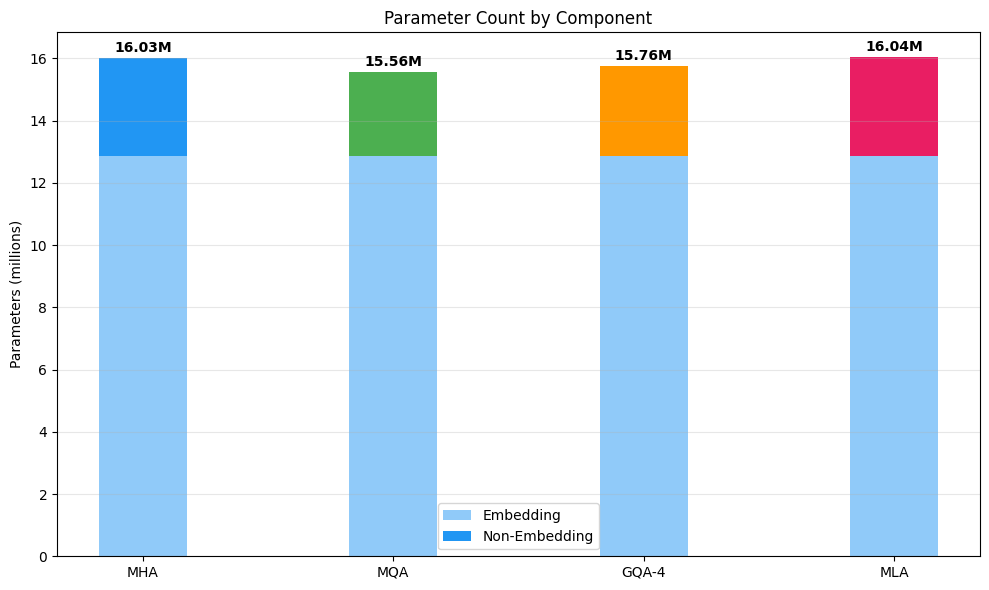

In [5]:
param_data = {}
print("Parameter Count Comparison")
print("=" * 70)
print(f"{'Model':<10} {'Total Params':>15} {'Non-Embed':>15} {'Embed':>15}")
print("-" * 70)

for name in model_names:
    for dataset in ['TinyStories', 'SimpleStories']:
        if name in models[dataset]:
            model = models[dataset][name]
            total = model.get_num_params()
            non_embed = model.get_num_params(non_embedding=True)
            embed = total - non_embed
            param_data[name] = {'total': total, 'non_embed': non_embed, 'embed': embed}
            print(f"{name:<10} {total:>15,} {non_embed:>15,} {embed:>15,}")
            break

print("=" * 70)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(model_names))
width = 0.35

embed_vals = [param_data[n]['embed'] / 1e6 for n in model_names]
non_embed_vals = [param_data[n]['non_embed'] / 1e6 for n in model_names]

bars1 = ax.bar(x, embed_vals, width, label='Embedding', color='#90CAF9')
bars2 = ax.bar(x, non_embed_vals, width, bottom=embed_vals, label='Non-Embedding', color=color_list)

ax.set_ylabel('Parameters (millions)')
ax.set_title('Parameter Count by Component')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()

for i, n in enumerate(model_names):
    total = param_data[n]['total'] / 1e6
    ax.text(i, total + 0.1, f'{total:.2f}M', ha='center', va='bottom', fontweight='bold')

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/parameter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. KV-Cache Size Analysis

KV-Cache Size per Token per Layer
  MHA     :  512 values  (1.000x of MHA, 100.0%)
  MQA     :   64 values  (0.125x of MHA, 12.5%)
  GQA-4   :  256 values  (0.500x of MHA, 50.0%)
  MLA     :  144 values  (0.281x of MHA, 28.1%)


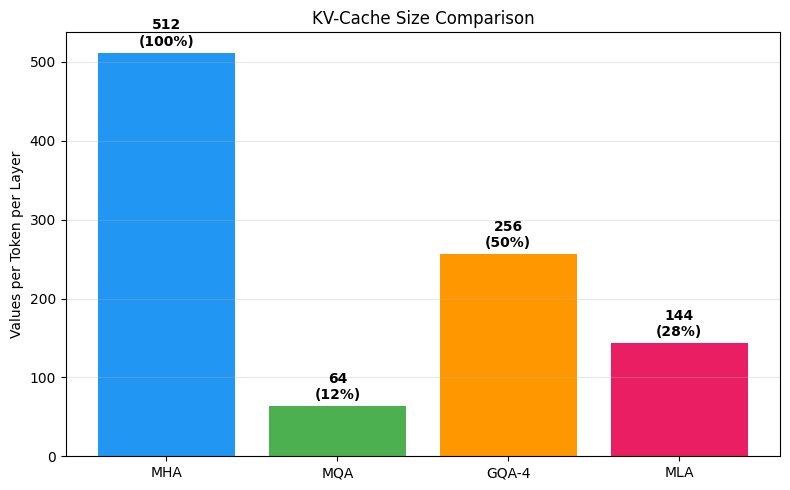

In [6]:
d_head = 256 // 8  # = 32
h = 8

kv_cache = {
    'MHA': 2 * h * d_head,        # 512 values per token per layer
    'MQA': 2 * 1 * d_head,        # 64 values
    'GQA-4': 2 * 4 * d_head,      # 256 values
    'MLA': 128 + 16,               # 144 values (d_c + d_rope)
}

print("KV-Cache Size per Token per Layer")
print("=" * 60)
for name, size in kv_cache.items():
    relative = size / kv_cache['MHA']
    print(f"  {name:<8}: {size:>4} values  ({relative:.3f}x of MHA, {relative*100:.1f}%)")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
names = list(kv_cache.keys())
sizes = list(kv_cache.values())
bars = ax.bar(names, sizes, color=color_list)
ax.set_ylabel('Values per Token per Layer')
ax.set_title('KV-Cache Size Comparison')
for bar, size, name in zip(bars, sizes, names):
    pct = size / kv_cache['MHA'] * 100
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{size}\n({pct:.0f}%)', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/kv_cache_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. FLOPs & Arithmetic Intensity

FLOPs & Arithmetic Intensity (per token, per layer)
Model          KV FLOPs   Attn FLOPs   KV Bytes   Arith Intens
--------------------------------------------------------------------------------
MHA             262,144      262,144      1,024          256.0
MQA              32,768      262,144        128          256.0
GQA-4           131,072      262,144        512          256.0
MLA             204,800      327,680        288          711.1


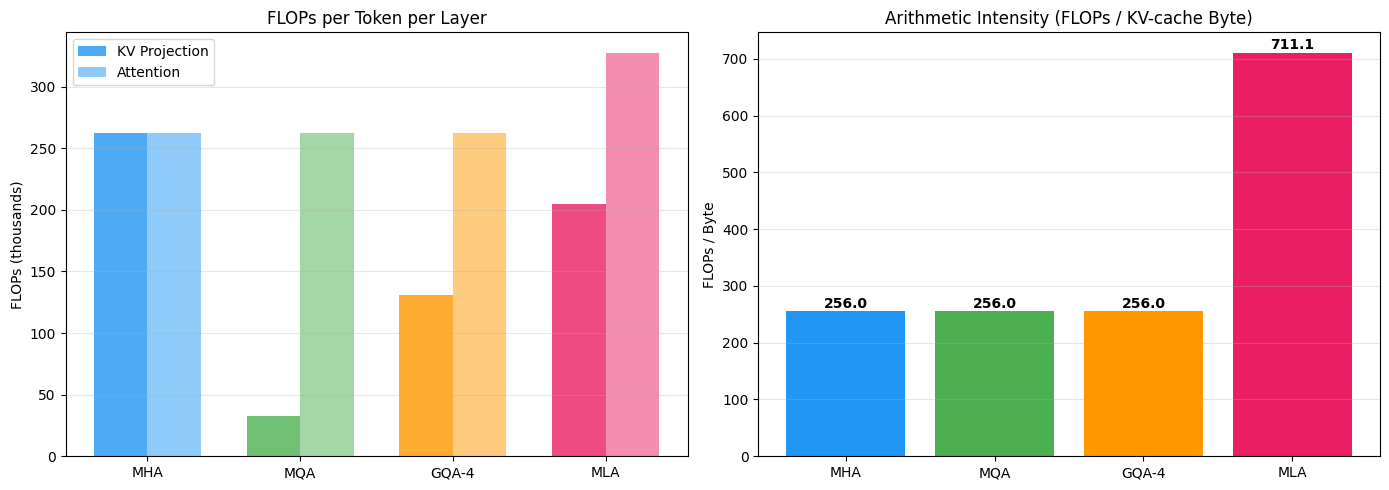

In [7]:
d_model = 256
d_head = 32
h = 8
d_c = 128
d_rope = 16
seq_len = 256
n_layers = 4
dtype_bytes = 2  # BFloat16

# KV computation FLOPs per token (projections only, per layer)
# FLOPs for matrix multiply: 2 * input_dim * output_dim per token
kv_flops = {
    'MHA': 2 * d_model * d_model + 2 * d_model * d_model,  # K + V projections (full d_model each)
    'MQA': 2 * d_model * d_head + 2 * d_model * d_head,    # K + V projections (single head each)
    'GQA-4': 2 * d_model * (4 * d_head) + 2 * d_model * (4 * d_head),  # K + V (4 KV heads each)
    'MLA': 2 * d_model * d_c + 2 * d_c * (h * d_head) + 2 * d_c * (h * d_head) + 2 * d_model * d_rope,  # down + up_K + up_V + rope_K
}

# Attention FLOPs per token per layer: Q*K^T + softmax + attn*V
# Q*K^T: 2 * h * d_head * seq_len, attn*V: 2 * h * seq_len * d_head
attn_flops = {name: 2 * h * d_head * seq_len + 2 * h * seq_len * d_head for name in model_names}
# MLA has larger effective d_head due to RoPE concatenation
mla_d_head_eff = d_head + d_rope
attn_flops['MLA'] = 2 * h * mla_d_head_eff * seq_len + 2 * h * seq_len * d_head

# KV-cache bytes per token per layer
kv_bytes = {name: kv_cache[name] * dtype_bytes for name in model_names}

# Arithmetic intensity = FLOPs / KV-cache-bytes
arith_intensity = {name: kv_flops[name] / kv_bytes[name] for name in model_names}

print("FLOPs & Arithmetic Intensity (per token, per layer)")
print("=" * 80)
print(f"{'Model':<10} {'KV FLOPs':>12} {'Attn FLOPs':>12} {'KV Bytes':>10} {'Arith Intens':>14}")
print("-" * 80)
for name in model_names:
    print(f"{name:<10} {kv_flops[name]:>12,} {attn_flops[name]:>12,} {kv_bytes[name]:>10,} {arith_intensity[name]:>14.1f}")
print("=" * 80)

# Dual bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# FLOPs comparison
x = np.arange(len(model_names))
width = 0.35
kv_vals = [kv_flops[n] / 1e3 for n in model_names]
attn_vals = [attn_flops[n] / 1e3 for n in model_names]
ax1.bar(x - width/2, kv_vals, width, label='KV Projection', color=color_list, alpha=0.8)
ax1.bar(x + width/2, attn_vals, width, label='Attention', color=color_list, alpha=0.5)
ax1.set_ylabel('FLOPs (thousands)')
ax1.set_title('FLOPs per Token per Layer')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Arithmetic intensity
ai_vals = [arith_intensity[n] for n in model_names]
bars = ax2.bar(model_names, ai_vals, color=color_list)
ax2.set_ylabel('FLOPs / Byte')
ax2.set_title('Arithmetic Intensity (FLOPs / KV-cache Byte)')
for bar, val in zip(bars, ai_vals):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/flops_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Validation Perplexity & Loss


Evaluating on TinyStories...

Setting up TinyStories datasets...
Loading TinyStories dataset (split=train)...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

...

data/train-00006-of-00007.parquet:   0%|          | 0.00/238M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2115696 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/21371 [00:00<?, ? examples/s]

Sampling 1000 from 2115696 examples...
Dataset size: 1000
Loading SimpleStories dataset (split=test)...
Sampling 5000 from 21371 examples...
Dataset size: 5000

Dataset Summary:
  Train samples: 1,000
  Val samples: 5,000
  Max sequence length: 256
  Batch size: 32
  Vocab size: 50257

  MHA: Loss=5.4639, PPL=236.01

Setting up SimpleStories datasets...
Loading SimpleStories dataset (split=train)...
Sampling 1000 from 2115696 examples...
Dataset size: 1000
Loading SimpleStories dataset (split=test)...
Sampling 5000 from 21371 examples...
Dataset size: 5000

Dataset Summary:
  Train samples: 1,000
  Val samples: 5,000
  Max sequence length: 256
  Batch size: 32
  Vocab size: 50257

  MQA: Loss=5.3886, PPL=218.91

Setting up SimpleStories datasets...
Loading SimpleStories dataset (split=train)...
Sampling 1000 from 2115696 examples...
Dataset size: 1000
Loading SimpleStories dataset (split=test)...
Sampling 5000 from 21371 examples...
Dataset size: 5000

Dataset Summary:
  Train samples:

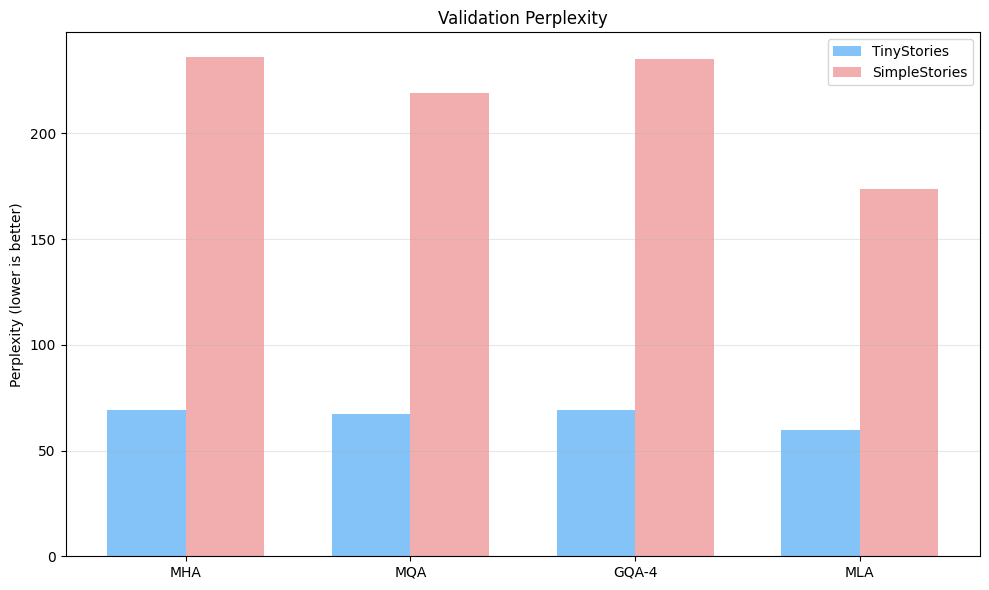

In [8]:
def evaluate_model(model, data_config, max_batches=100):
    """Evaluate model on validation set, return avg loss and perplexity"""
    data_cfg = {
        'dataset_name': data_config['dataset_name'],
        'tokenizer': 'gpt2',
        'train_samples': 1000,
        'val_samples': 5000,
        'batch_size': 32,
        'max_seq_length': 256,
        'num_workers': 2,
        'pin_memory': True,
        'text_column': data_config.get('text_column', 'text'),
        'val_split': data_config.get('val_split', 'validation'),
    }
    dm = TinyStoriesDataModule(data_cfg)
    dm.setup()
    val_loader = dm.val_dataloader()

    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            if i >= max_batches:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            logits = model(input_ids)
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = input_ids[:, 1:].contiguous()
            shift_mask = attention_mask[:, 1:].contiguous()

            loss = F.cross_entropy(shift_logits.view(-1, shift_logits.size(-1)),
                                   shift_labels.view(-1), reduction='none')
            loss = (loss * shift_mask.view(-1)).sum()
            total_loss += loss.item()
            total_tokens += shift_mask.sum().item()

    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)
    return avg_loss, perplexity

# Evaluate all models
results = {}
for dataset in ['TinyStories', 'SimpleStories']:
    results[dataset] = {}
    print(f"\nEvaluating on {dataset}...")
    for name in model_names:
        if name in models[dataset]:
            loss, ppl = evaluate_model(models[dataset][name], data_configs[dataset])
            results[dataset][name] = {'loss': loss, 'perplexity': ppl}
            print(f"  {name}: Loss={loss:.4f}, PPL={ppl:.2f}")

# Summary table
print("\nPerplexity Summary")
print("=" * 60)
print(f"{'Model':<10} {'TinyStories PPL':>18} {'SimpleStories PPL':>18}")
print("-" * 60)
for name in model_names:
    ts_ppl = results.get('TinyStories', {}).get(name, {}).get('perplexity', 'N/A')
    ss_ppl = results.get('SimpleStories', {}).get(name, {}).get('perplexity', 'N/A')
    ts_str = f"{ts_ppl:.2f}" if isinstance(ts_ppl, float) else ts_ppl
    ss_str = f"{ss_ppl:.2f}" if isinstance(ss_ppl, float) else ss_ppl
    print(f"{name:<10} {ts_str:>18} {ss_str:>18}")

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(model_names))
width = 0.35
for i, dataset in enumerate(['TinyStories', 'SimpleStories']):
    ppls = [results.get(dataset, {}).get(n, {}).get('perplexity', 0) for n in model_names]
    ax.bar(x + i*width, ppls, width, label=dataset, alpha=0.8,
           color=['#64B5F6' if i == 0 else '#EF9A9A'] * len(model_names))
ax.set_ylabel('Perplexity (lower is better)')
ax.set_title('Validation Perplexity')
ax.set_xticks(x + width/2)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/perplexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Top-1 / Top-5 / Top-10 Accuracy


Computing accuracy on TinyStories...

Setting up TinyStories datasets...
Loading TinyStories dataset (split=train)...
Sampling 1000 from 2119719 examples...
Dataset size: 1000
Loading TinyStories dataset (split=validation)...
Sampling 5000 from 21990 examples...
Dataset size: 5000

Dataset Summary:
  Train samples: 1,000
  Val samples: 5,000
  Max sequence length: 256
  Batch size: 32
  Vocab size: 50257

  MHA: Top-1=33.65%, Top-5=54.88%, Top-10=63.09%

Setting up TinyStories datasets...
Loading TinyStories dataset (split=train)...
Sampling 1000 from 2119719 examples...
Dataset size: 1000
Loading TinyStories dataset (split=validation)...
Sampling 5000 from 21990 examples...
Dataset size: 5000

Dataset Summary:
  Train samples: 1,000
  Val samples: 5,000
  Max sequence length: 256
  Batch size: 32
  Vocab size: 50257

  MQA: Top-1=33.73%, Top-5=55.14%, Top-10=63.39%

Setting up TinyStories datasets...
Loading TinyStories dataset (split=train)...
Sampling 1000 from 2119719 examples...


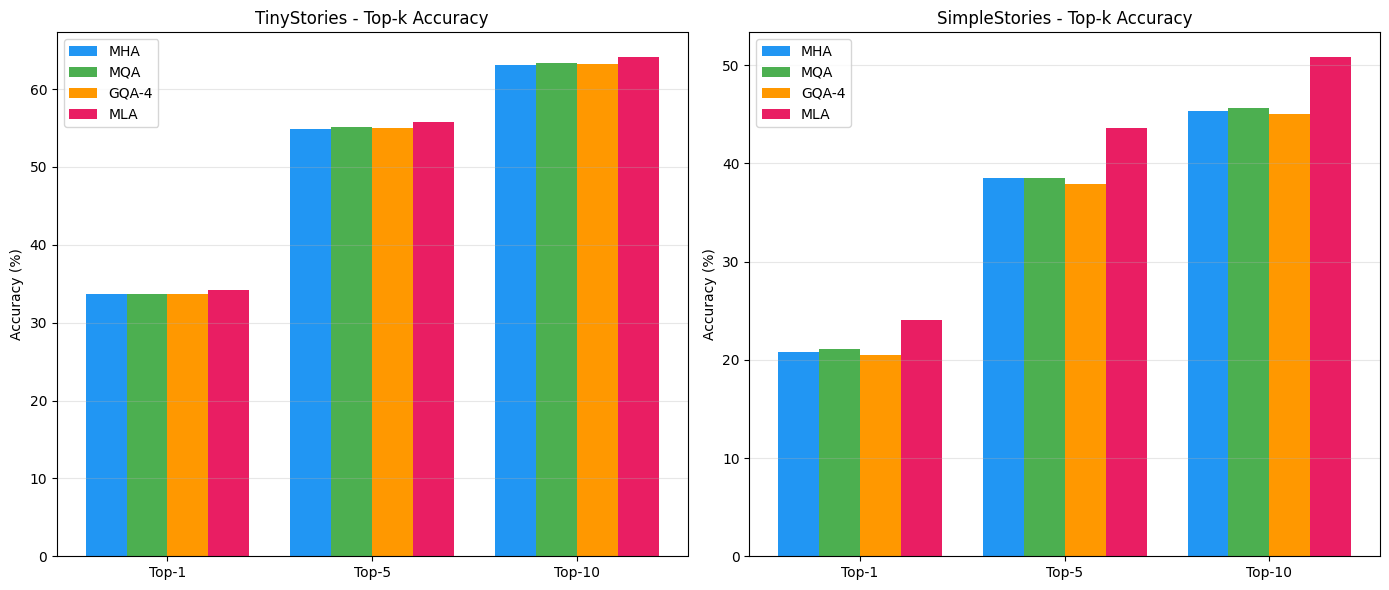

In [9]:
def compute_topk_accuracy(model, data_config, k_values=[1, 5, 10], max_batches=100):
    """Compute top-k accuracy for next token prediction"""
    data_cfg = {
        'dataset_name': data_config['dataset_name'],
        'tokenizer': 'gpt2',
        'train_samples': 1000,
        'val_samples': 5000,
        'batch_size': 32,
        'max_seq_length': 256,
        'num_workers': 2,
        'pin_memory': True,
        'text_column': data_config.get('text_column', 'text'),
        'val_split': data_config.get('val_split', 'validation'),
    }
    dm = TinyStoriesDataModule(data_cfg)
    dm.setup()
    val_loader = dm.val_dataloader()

    correct = {k: 0 for k in k_values}
    total = 0

    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            if i >= max_batches:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            logits = model(input_ids)
            shift_logits = logits[:, :-1, :]
            shift_labels = input_ids[:, 1:]
            shift_mask = attention_mask[:, 1:]

            for k in k_values:
                _, topk_preds = torch.topk(shift_logits, k, dim=-1)
                matches = (topk_preds == shift_labels.unsqueeze(-1)).any(dim=-1)
                correct[k] += (matches * shift_mask).sum().item()

            total += shift_mask.sum().item()

    return {k: correct[k] / total * 100 for k in k_values}

# Compute accuracies
acc_results = {}
for dataset in ['TinyStories', 'SimpleStories']:
    acc_results[dataset] = {}
    print(f"\nComputing accuracy on {dataset}...")
    for name in model_names:
        if name in models[dataset]:
            topk = compute_topk_accuracy(models[dataset][name], data_configs[dataset])
            acc_results[dataset][name] = topk
            print(f"  {name}: Top-1={topk[1]:.2f}%, Top-5={topk[5]:.2f}%, Top-10={topk[10]:.2f}%")

# Grouped bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, dataset in zip([ax1, ax2], ['TinyStories', 'SimpleStories']):
    x = np.arange(3)  # Top-1, Top-5, Top-10
    width = 0.2
    for i, name in enumerate(model_names):
        if name in acc_results.get(dataset, {}):
            accs = [acc_results[dataset][name][k] for k in [1, 5, 10]]
            ax.bar(x + i*width, accs, width, label=name, color=colors[name])
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{dataset} - Top-k Accuracy')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(['Top-1', 'Top-5', 'Top-10'])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/topk_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Generation Quality

In [10]:
def compute_distinct_n(texts, n):
    """Compute distinct-n: unique n-grams / total n-grams"""
    all_ngrams = []
    for text in texts:
        tokens = text.split()
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        all_ngrams.extend(ngrams)
    if not all_ngrams:
        return 0.0
    return len(set(all_ngrams)) / len(all_ngrams)


def compute_repetition_rate(texts, n=3):
    """Compute repetition rate: fraction of repeated n-grams"""
    total_ngrams = 0
    repeated_ngrams = 0
    for text in texts:
        tokens = text.split()
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        counts = Counter(ngrams)
        total_ngrams += len(ngrams)
        repeated_ngrams += sum(c - 1 for c in counts.values() if c > 1)
    if total_ngrams == 0:
        return 0.0
    return repeated_ngrams / total_ngrams


prompts = ["Once upon a time", "One day, a little girl", "In a big forest", "There was a happy dog"]

# Generate and display side-by-side samples
for dataset in ['TinyStories', 'SimpleStories']:
    print(f"\n{'='*80}")
    print(f"Generated Stories ({dataset})")
    print(f"{'='*80}")

    for prompt in prompts:
        print(f"\nPrompt: \"{prompt}\"")
        print("-" * 80)

        for name in model_names:
            if name in models[dataset]:
                model = models[dataset][name]
                input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
                with torch.no_grad():
                    output = model.generate(input_ids, max_length=100, temperature=0.8, top_k=50, top_p=0.95)
                text = tokenizer.decode(output[0], skip_special_tokens=True)
                print(f"\n  [{name}]: {text[:200]}")
        print()


Generated Stories (TinyStories)

Prompt: "Once upon a time"
--------------------------------------------------------------------------------

  [MHA]: Once upon a time, there was a little girl named Lily. She loved to play with her mommy and her mommy. One day, they saw a big sky. Lily had a big grass, and a new cat. 

One day, Lily's mommy started 

  [MQA]: Once upon a time, there was a little boy named Lily. She loved to play with her mommy. One day, he saw a big, a little girl named Lily. She was so excited. She ran in a kind, but the, she said, "Yes, 

  [GQA-4]: Once upon a time, there was a little girl named Timmy. Timmy loved to play with her mommy and stay at the man. One day, Timmy's mommy started to play with her friend. Timmy saw a big dog and got a big

  [MLA]: Once upon a time, there was a little girl named Lily. She loved to play with her mom. One day, she didn't want to play with her parents.

But then, they were a big, Lily said, "I want to eat it." 

So


Prompt: "O


Diversity metrics for TinyStories:
  MHA: D1=0.0836, D2=0.3544, D3=0.6337, Rep=0.0203
  MQA: D1=0.0893, D2=0.3760, D3=0.6669, Rep=0.0128
  GQA-4: D1=0.0894, D2=0.3742, D3=0.6462, Rep=0.0165
  MLA: D1=0.0929, D2=0.3778, D3=0.6555, Rep=0.0130

Diversity metrics for SimpleStories:
  MHA: D1=0.0687, D2=0.4305, D3=0.8403, Rep=0.0028
  MQA: D1=0.0658, D2=0.4177, D3=0.8321, Rep=0.0033
  GQA-4: D1=0.0690, D2=0.4416, D3=0.8506, Rep=0.0032
  MLA: D1=0.0833, D2=0.4325, D3=0.7957, Rep=0.0052


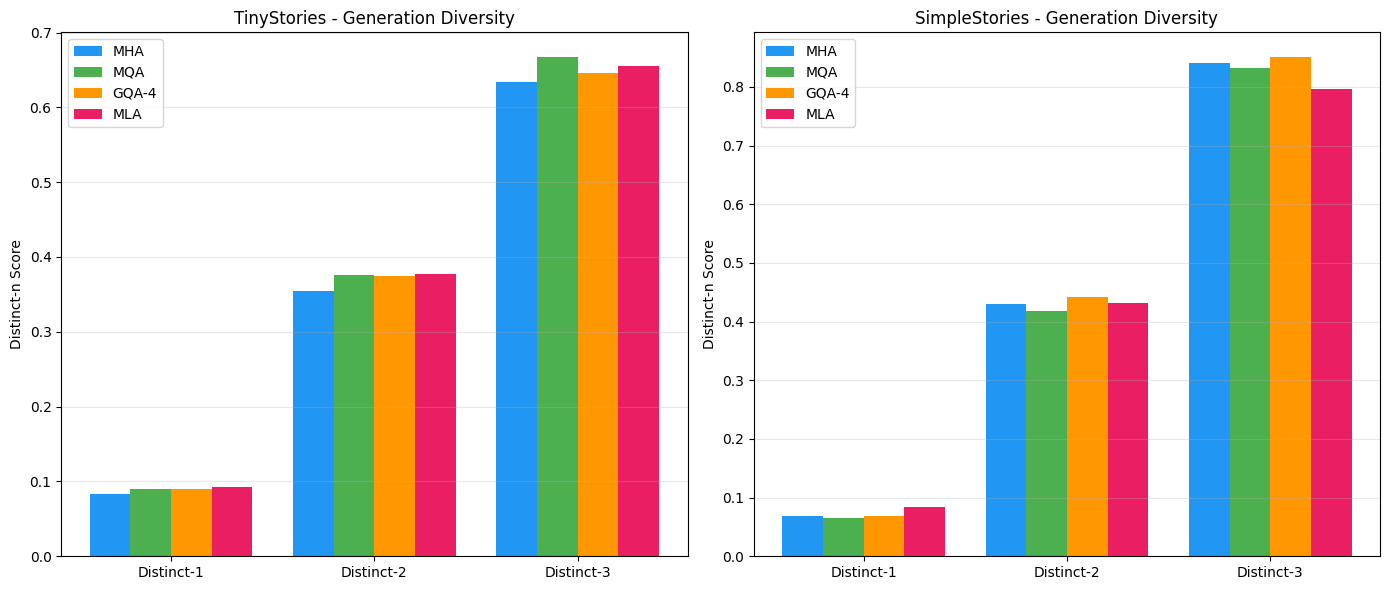

In [11]:
# Diversity metrics
diversity_results = {}

for dataset in ['TinyStories', 'SimpleStories']:
    diversity_results[dataset] = {}
    print(f"\nDiversity metrics for {dataset}:")
    for name in model_names:
        if name in models[dataset]:
            model = models[dataset][name]
            # Generate 80 texts (20 per prompt)
            texts = []
            for prompt in prompts:
                for _ in range(20):
                    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
                    with torch.no_grad():
                        output = model.generate(input_ids, max_length=100, temperature=0.8, top_k=50, top_p=0.95)
                    texts.append(tokenizer.decode(output[0], skip_special_tokens=True))

            d1 = compute_distinct_n(texts, 1)
            d2 = compute_distinct_n(texts, 2)
            d3 = compute_distinct_n(texts, 3)
            rep = compute_repetition_rate(texts)
            diversity_results[dataset][name] = {'d1': d1, 'd2': d2, 'd3': d3, 'rep': rep}
            print(f"  {name}: D1={d1:.4f}, D2={d2:.4f}, D3={d3:.4f}, Rep={rep:.4f}")

# Bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, dataset in zip([ax1, ax2], ['TinyStories', 'SimpleStories']):
    x = np.arange(3)
    width = 0.2
    for i, name in enumerate(model_names):
        if name in diversity_results.get(dataset, {}):
            d = diversity_results[dataset][name]
            vals = [d['d1'], d['d2'], d['d3']]
            ax.bar(x + i*width, vals, width, label=name, color=colors[name])
    ax.set_ylabel('Distinct-n Score')
    ax.set_title(f'{dataset} - Generation Diversity')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(['Distinct-1', 'Distinct-2', 'Distinct-3'])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/generation_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Inference Speed

MHA: seq64=11,445, seq128=22,972, seq256=44,187 tok/s
MQA: seq64=11,549, seq128=23,080, seq256=43,011 tok/s
GQA-4: seq64=10,239, seq128=22,728, seq256=43,177 tok/s
MLA: seq64=10,587, seq128=20,963, seq256=40,030 tok/s


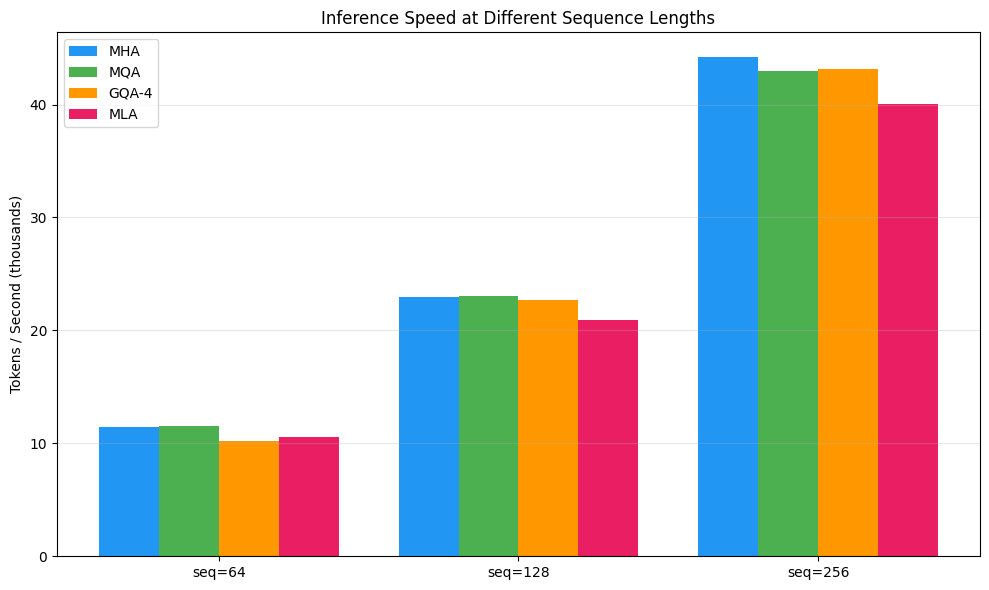

In [12]:
def benchmark_speed(model, seq_length, num_runs=10, batch_size=1):
    """Benchmark forward-pass speed in tokens/sec"""
    model.eval()
    input_ids = torch.randint(0, 50257, (batch_size, seq_length)).to(device)

    # Warmup
    for _ in range(5):
        with torch.no_grad():
            _ = model(input_ids)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_ids)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end = time.perf_counter()

    total_tokens = batch_size * seq_length * num_runs
    tokens_per_sec = total_tokens / (end - start)
    return tokens_per_sec

seq_lengths = [64, 128, 256]
speed_results = {}

for name in model_names:
    # Use TinyStories model for speed benchmarks
    for dataset in ['TinyStories', 'SimpleStories']:
        if name in models[dataset]:
            speed_results[name] = {}
            for sl in seq_lengths:
                speed = benchmark_speed(models[dataset][name], sl)
                speed_results[name][sl] = speed
            print(f"{name}: " + ", ".join(f"seq{sl}={speed_results[name][sl]:,.0f}" for sl in seq_lengths) + " tok/s")
            break

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(seq_lengths))
width = 0.2
for i, name in enumerate(model_names):
    if name in speed_results:
        speeds = [speed_results[name][sl] / 1000 for sl in seq_lengths]
        ax.bar(x + i*width, speeds, width, label=name, color=colors[name])
ax.set_ylabel('Tokens / Second (thousands)')
ax.set_title('Inference Speed at Different Sequence Lengths')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'seq={sl}' for sl in seq_lengths])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/inference_speed.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Peak GPU Memory

MHA: 2046.3 MB peak GPU memory
MQA: 2039.5 MB peak GPU memory
GQA-4: 2032.7 MB peak GPU memory
MLA: 2025.9 MB peak GPU memory


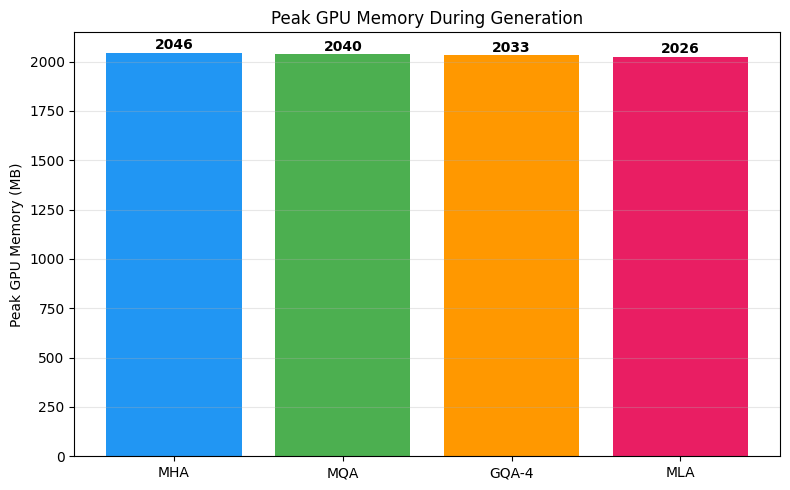

In [13]:
memory_results = {}

for name in model_names:
    for dataset in ['TinyStories', 'SimpleStories']:
        if name in models[dataset]:
            model = models[dataset][name]
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()

            input_ids = tokenizer.encode("Once upon a time", return_tensors='pt').to(device)
            with torch.no_grad():
                output = model.generate(input_ids, max_length=100, temperature=0.8)

            peak_mb = torch.cuda.max_memory_allocated() / (1024 * 1024)
            memory_results[name] = peak_mb
            print(f"{name}: {peak_mb:.1f} MB peak GPU memory")
            break

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
names = list(memory_results.keys())
mems = [memory_results[n] for n in names]
bars = ax.bar(names, mems, color=[colors[n] for n in names])
ax.set_ylabel('Peak GPU Memory (MB)')
ax.set_title('Peak GPU Memory During Generation')
for bar, mem in zip(bars, mems):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{mem:.0f}', ha='center', va='bottom', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/peak_memory.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Attention Pattern Analysis

Computing attention entropy...

Setting up TinyStories datasets...
Loading TinyStories dataset (split=train)...
Sampling 1000 from 2119719 examples...
Dataset size: 1000
Loading TinyStories dataset (split=validation)...
Sampling 2000 from 21990 examples...
Dataset size: 2000

Dataset Summary:
  Train samples: 1,000
  Val samples: 2,000
  Max sequence length: 256
  Batch size: 16
  Vocab size: 50257

  MHA: L0=2.805, L1=0.736, L2=0.436, L3=0.762

Setting up TinyStories datasets...
Loading TinyStories dataset (split=train)...
Sampling 1000 from 2119719 examples...
Dataset size: 1000
Loading TinyStories dataset (split=validation)...
Sampling 2000 from 21990 examples...
Dataset size: 2000

Dataset Summary:
  Train samples: 1,000
  Val samples: 2,000
  Max sequence length: 256
  Batch size: 16
  Vocab size: 50257

  MQA: L0=2.738, L1=0.474, L2=0.503, L3=0.428

Setting up TinyStories datasets...
Loading TinyStories dataset (split=train)...
Sampling 1000 from 2119719 examples...
Dataset size:

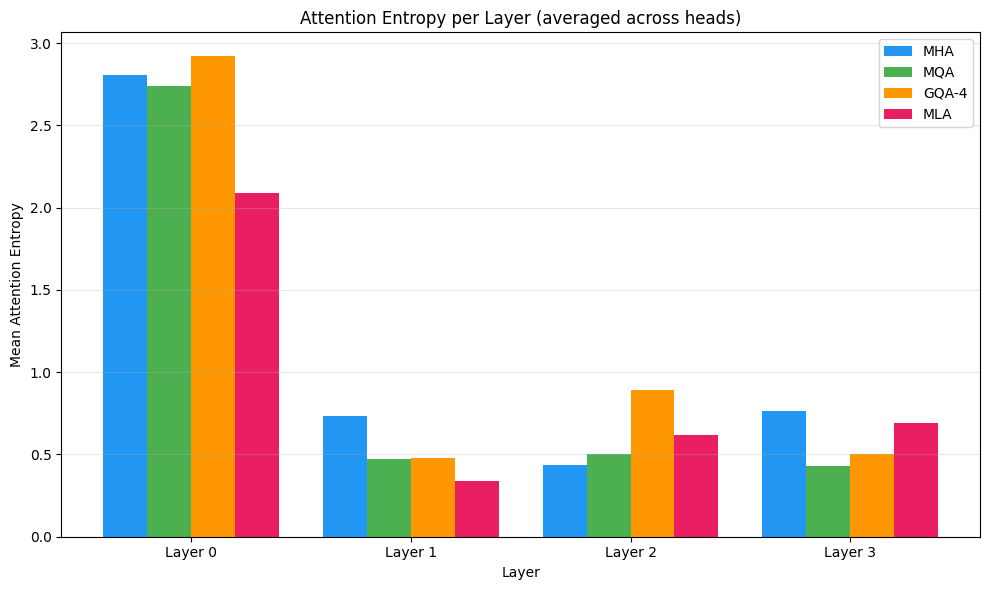

In [14]:
def compute_attention_entropy(model, data_config, max_batches=5):
    """Compute average attention entropy per layer per head.

    Hooks into model.transformer.blocks[i].attn to capture weights.
    Returns dict: {layer_idx: {head_idx: entropy_value}}
    """
    data_cfg = {
        'dataset_name': data_config['dataset_name'],
        'tokenizer': 'gpt2',
        'train_samples': 1000,
        'val_samples': 2000,
        'batch_size': 16,
        'max_seq_length': 256,
        'num_workers': 2,
        'pin_memory': True,
        'text_column': data_config.get('text_column', 'text'),
        'val_split': data_config.get('val_split', 'validation'),
    }
    dm = TinyStoriesDataModule(data_cfg)
    dm.setup()
    val_loader = dm.val_dataloader()

    model.eval()
    attention_weights = {}

    def hook_fn(name):
        def hook(module, input, output):
            # output is (attn_output, attn_weights) or just attn_output
            if isinstance(output, tuple) and len(output) > 1:
                attn = output[1]
                if attn is not None:
                    attention_weights[name] = attn.detach()
        return hook

    # Register hooks on model.transformer.blocks[i].attn
    hooks = []
    blocks = model.transformer.blocks
    for i, block in enumerate(blocks):
        if hasattr(block, 'attn'):
            h = block.attn.register_forward_hook(hook_fn(f'layer_{i}'))
            hooks.append(h)

    # Collect entropies
    n_layers = len(blocks)
    all_entropies = {i: [] for i in range(n_layers)}

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            if batch_idx >= max_batches:
                break

            input_ids = batch['input_ids'].to(device)
            _ = model(input_ids)

            for i in range(n_layers):
                key = f'layer_{i}'
                if key in attention_weights:
                    attn = attention_weights[key]  # (batch, heads, seq, seq)
                    attn = attn + 1e-10
                    entropy = -torch.sum(attn * torch.log(attn), dim=-1)  # (batch, heads, seq)
                    # Mean entropy per head
                    head_entropy = entropy.mean(dim=(0, 2))  # (heads,)
                    all_entropies[i].append(head_entropy.cpu().numpy())

    # Cleanup hooks
    for h in hooks:
        h.remove()

    # Average across batches
    avg_entropies = {}
    for i in range(n_layers):
        if all_entropies[i]:
            avg_entropies[i] = np.mean(all_entropies[i], axis=0)  # (heads,)
        else:
            avg_entropies[i] = np.zeros(8)

    return avg_entropies


# Compute entropy for all models (using TinyStories)
entropy_results = {}
print("Computing attention entropy...")
for name in model_names:
    if name in models['TinyStories']:
        try:
            entropy_results[name] = compute_attention_entropy(
                models['TinyStories'][name], data_configs['TinyStories'])
            avg_per_layer = [entropy_results[name][i].mean() for i in range(4)]
            print(f"  {name}: " + ", ".join(f"L{i}={e:.3f}" for i, e in enumerate(avg_per_layer)))
        except Exception as e:
            print(f"  {name}: FAILED - {e}")

# Grouped bar: x=layer, groups=mechanism
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(4)  # 4 layers
width = 0.2
for i, name in enumerate(model_names):
    if name in entropy_results:
        layer_means = [entropy_results[name][l].mean() for l in range(4)]
        ax.bar(x + i*width, layer_means, width, label=name, color=colors[name])
ax.set_xlabel('Layer')
ax.set_ylabel('Mean Attention Entropy')
ax.set_title('Attention Entropy per Layer (averaged across heads)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Layer 0', 'Layer 1', 'Layer 2', 'Layer 3'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/attention_entropy.png', dpi=150, bbox_inches='tight')
plt.show()

MHA: captured 4 layers
MQA: captured 4 layers
GQA-4: captured 4 layers
MLA: captured 4 layers


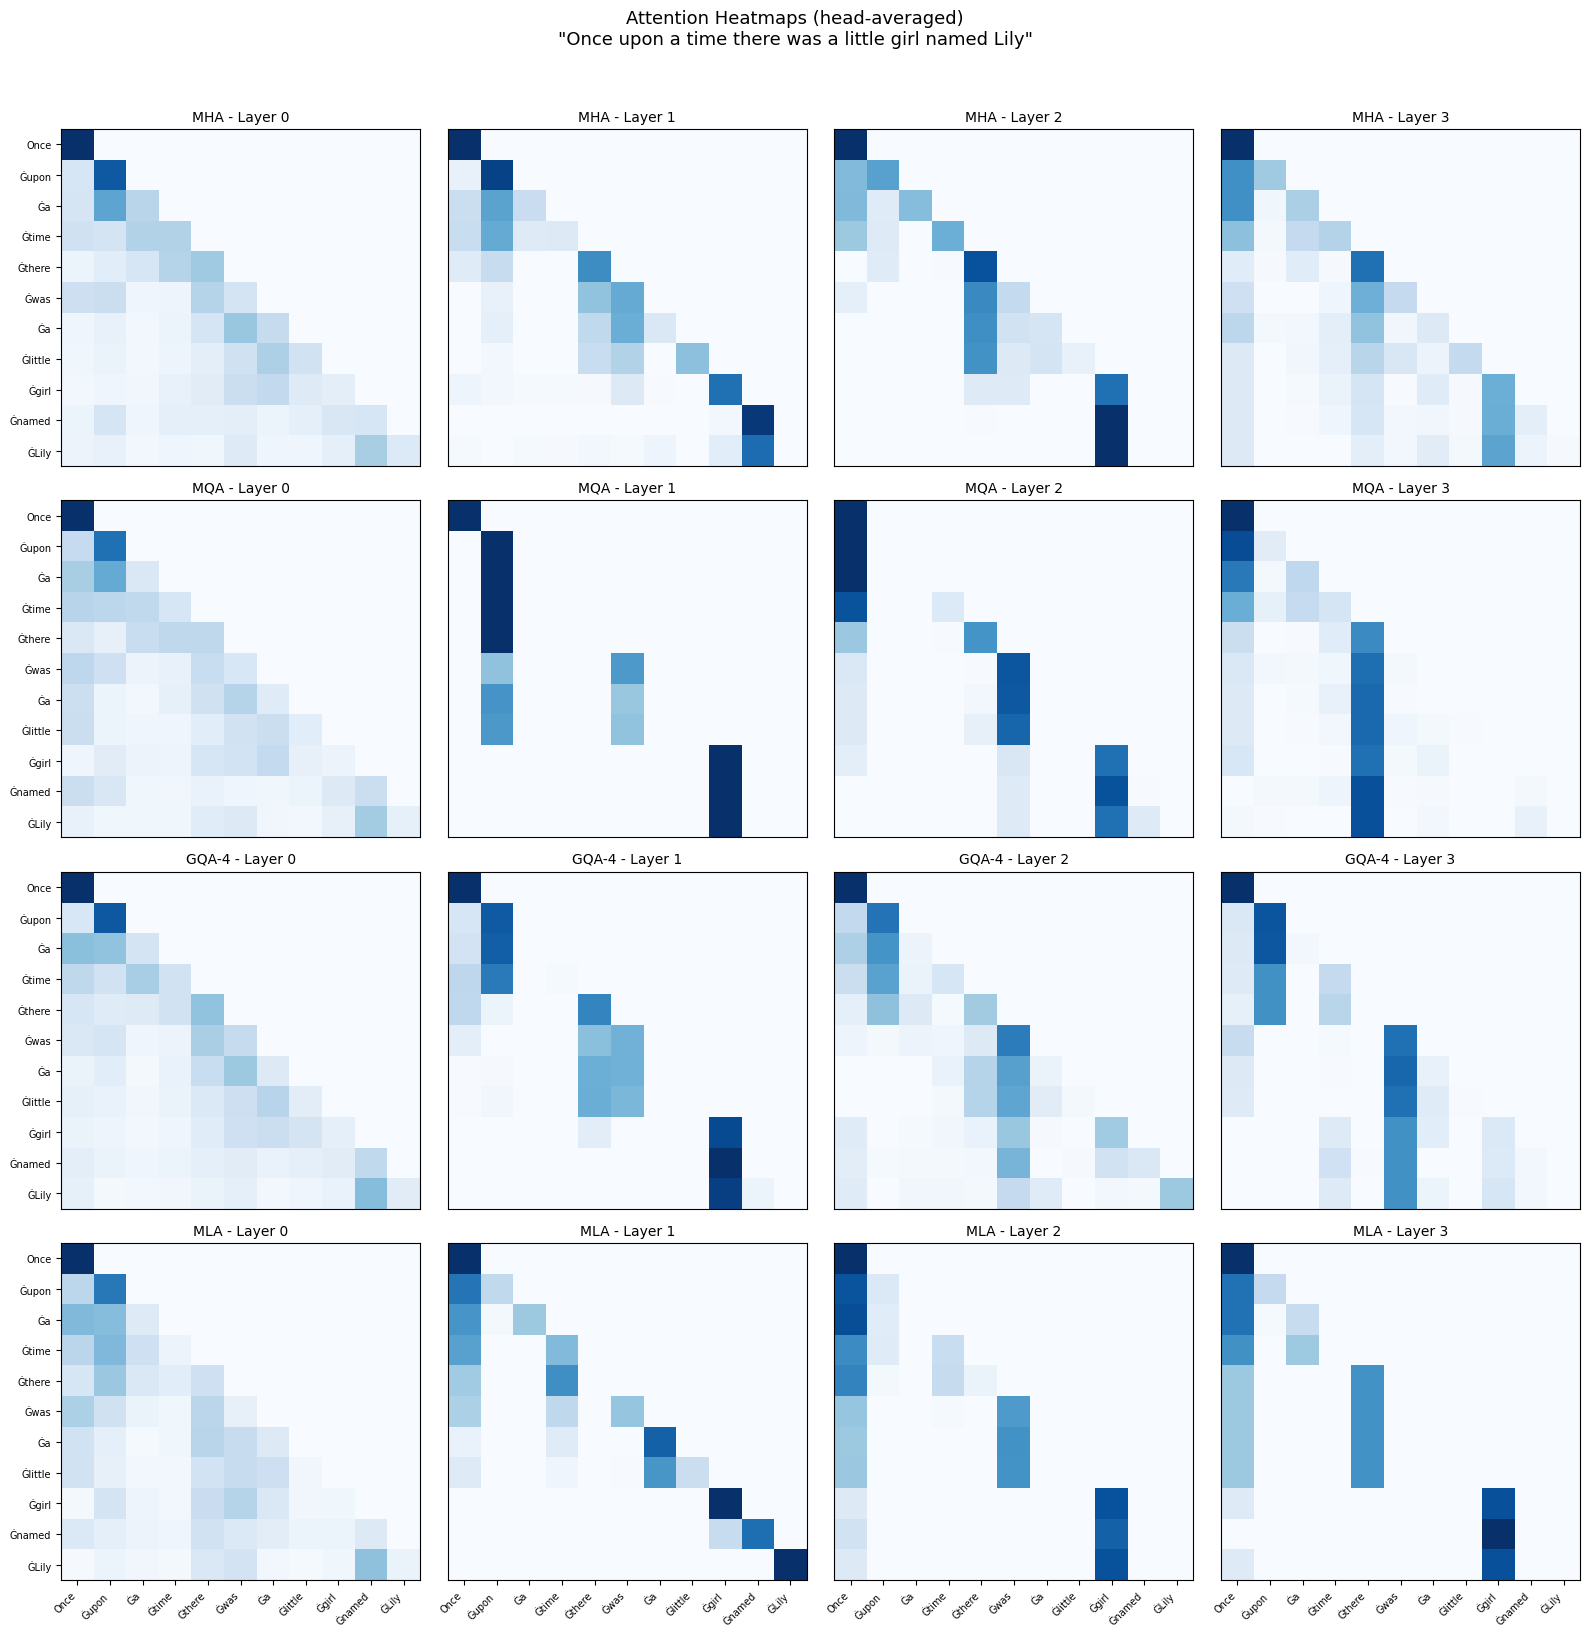

In [15]:
# Attention heatmaps
test_sentence = "Once upon a time there was a little girl named Lily"
input_ids = tokenizer.encode(test_sentence, return_tensors='pt').to(device)
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

def get_attention_maps(model, input_ids):
    """Get attention maps from all layers"""
    attention_maps = {}

    def hook_fn(name):
        def hook(module, input, output):
            if isinstance(output, tuple) and len(output) > 1:
                attn = output[1]
                if attn is not None:
                    attention_maps[name] = attn.detach().cpu()
        return hook

    hooks = []
    for i, block in enumerate(model.transformer.blocks):
        if hasattr(block, 'attn'):
            h = block.attn.register_forward_hook(hook_fn(f'layer_{i}'))
            hooks.append(h)

    with torch.no_grad():
        _ = model(input_ids)

    for h in hooks:
        h.remove()

    return attention_maps

# Collect attention maps from all models
all_attn_maps = {}
for name in model_names:
    if name in models['TinyStories']:
        try:
            all_attn_maps[name] = get_attention_maps(models['TinyStories'][name], input_ids)
            print(f"{name}: captured {len(all_attn_maps[name])} layers")
        except Exception as e:
            print(f"{name}: FAILED - {e}")

# 4x4 grid: rows=mechanisms, cols=layers, head-averaged
available = [n for n in model_names if n in all_attn_maps]
n_models = len(available)
n_layers = 4

fig, axes = plt.subplots(n_models, n_layers, figsize=(16, 4 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]

for row, name in enumerate(available):
    for col in range(n_layers):
        key = f'layer_{col}'
        if key in all_attn_maps[name]:
            attn = all_attn_maps[name][key][0]  # (heads, seq, seq)
            avg_attn = attn.mean(dim=0).numpy()  # (seq, seq)
            im = axes[row, col].imshow(avg_attn, cmap='Blues', aspect='auto')
            axes[row, col].set_title(f'{name} - Layer {col}', fontsize=10)
            if col == 0:
                axes[row, col].set_yticks(range(len(tokens)))
                axes[row, col].set_yticklabels(tokens, fontsize=7)
            else:
                axes[row, col].set_yticks([])
            if row == n_models - 1:
                axes[row, col].set_xticks(range(len(tokens)))
                axes[row, col].set_xticklabels(tokens, rotation=45, ha='right', fontsize=7)
            else:
                axes[row, col].set_xticks([])
        else:
            axes[row, col].text(0.5, 0.5, 'N/A', ha='center', va='center')

plt.suptitle(f'Attention Heatmaps (head-averaged)\n"{test_sentence}"', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/attention_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

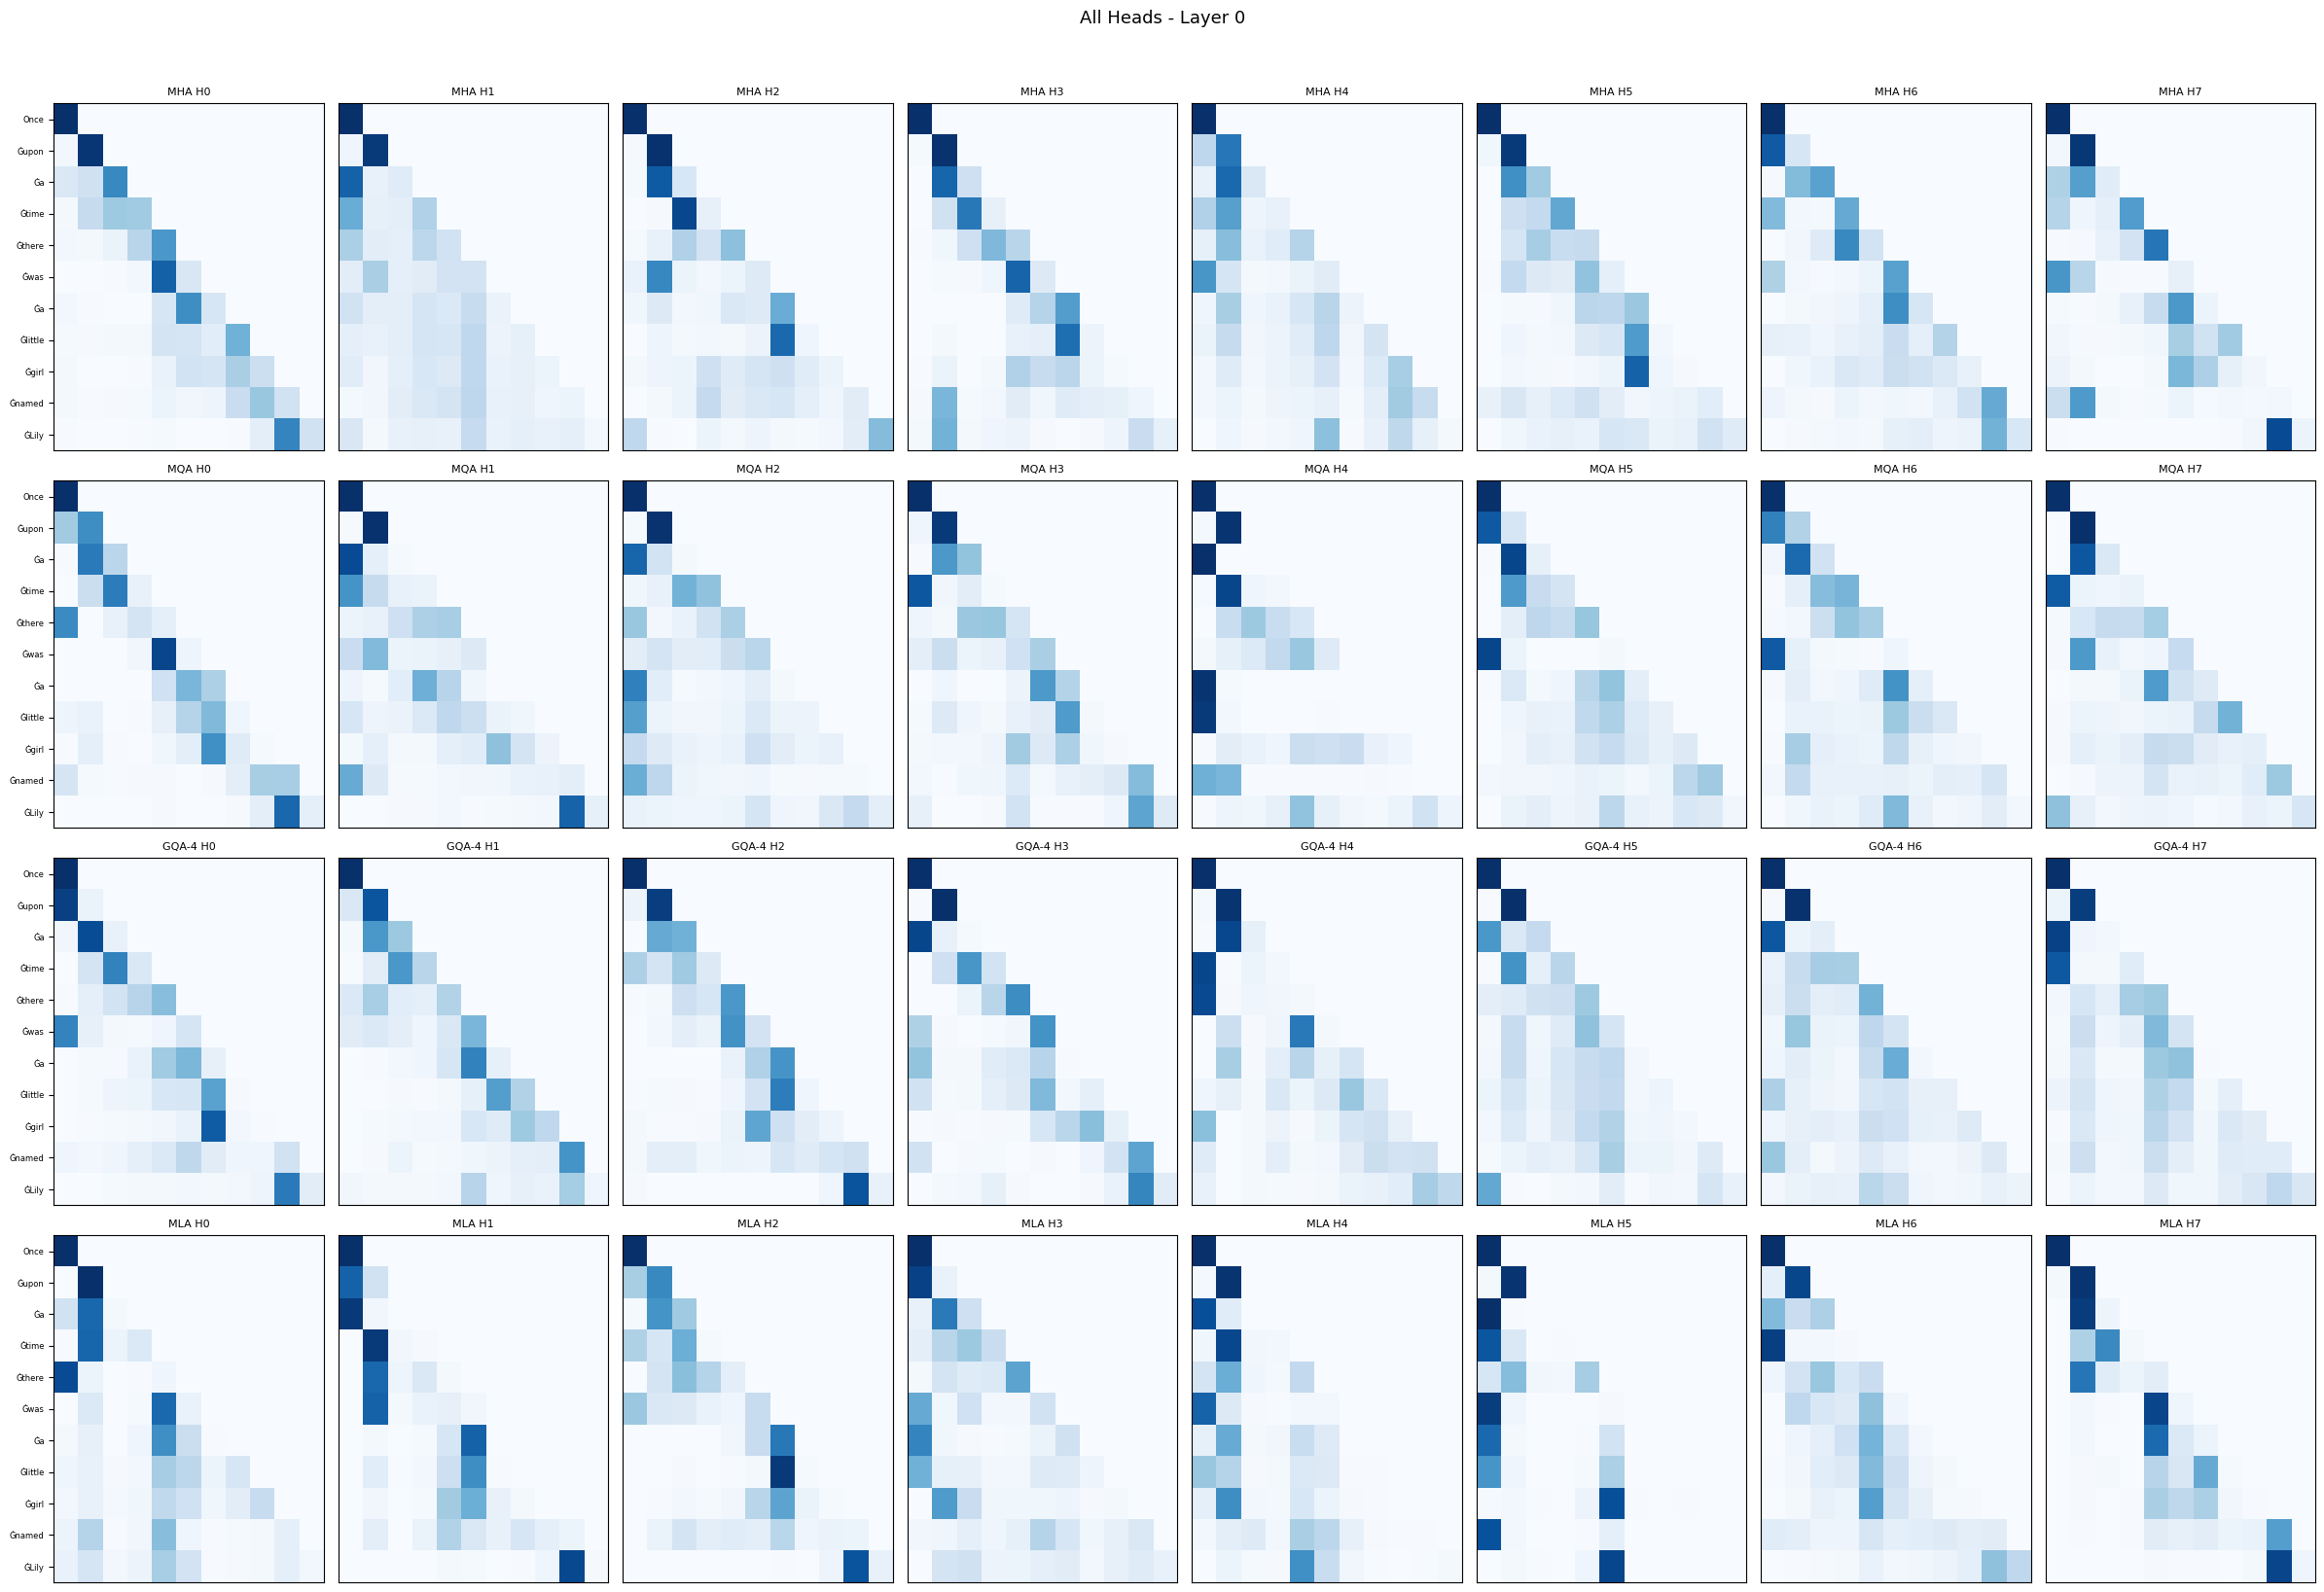

In [16]:
# Per-head heatmaps for layer 0 (4 mechanisms x 8 heads)
fig, axes = plt.subplots(n_models, 8, figsize=(24, 4 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]

for row, name in enumerate(available):
    key = 'layer_0'
    if key in all_attn_maps[name]:
        attn = all_attn_maps[name][key][0]  # (heads, seq, seq)
        n_heads = attn.shape[0]
        for head in range(min(n_heads, 8)):
            im = axes[row, head].imshow(attn[head].numpy(), cmap='Blues', aspect='auto')
            axes[row, head].set_title(f'{name} H{head}', fontsize=8)
            axes[row, head].set_xticks([])
            if head == 0:
                axes[row, head].set_yticks(range(len(tokens)))
                axes[row, head].set_yticklabels(tokens, fontsize=6)
            else:
                axes[row, head].set_yticks([])

plt.suptitle('All Heads - Layer 0', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/attention_heatmaps_heads.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Training Curves

Copied logs from Drive to /content/logs


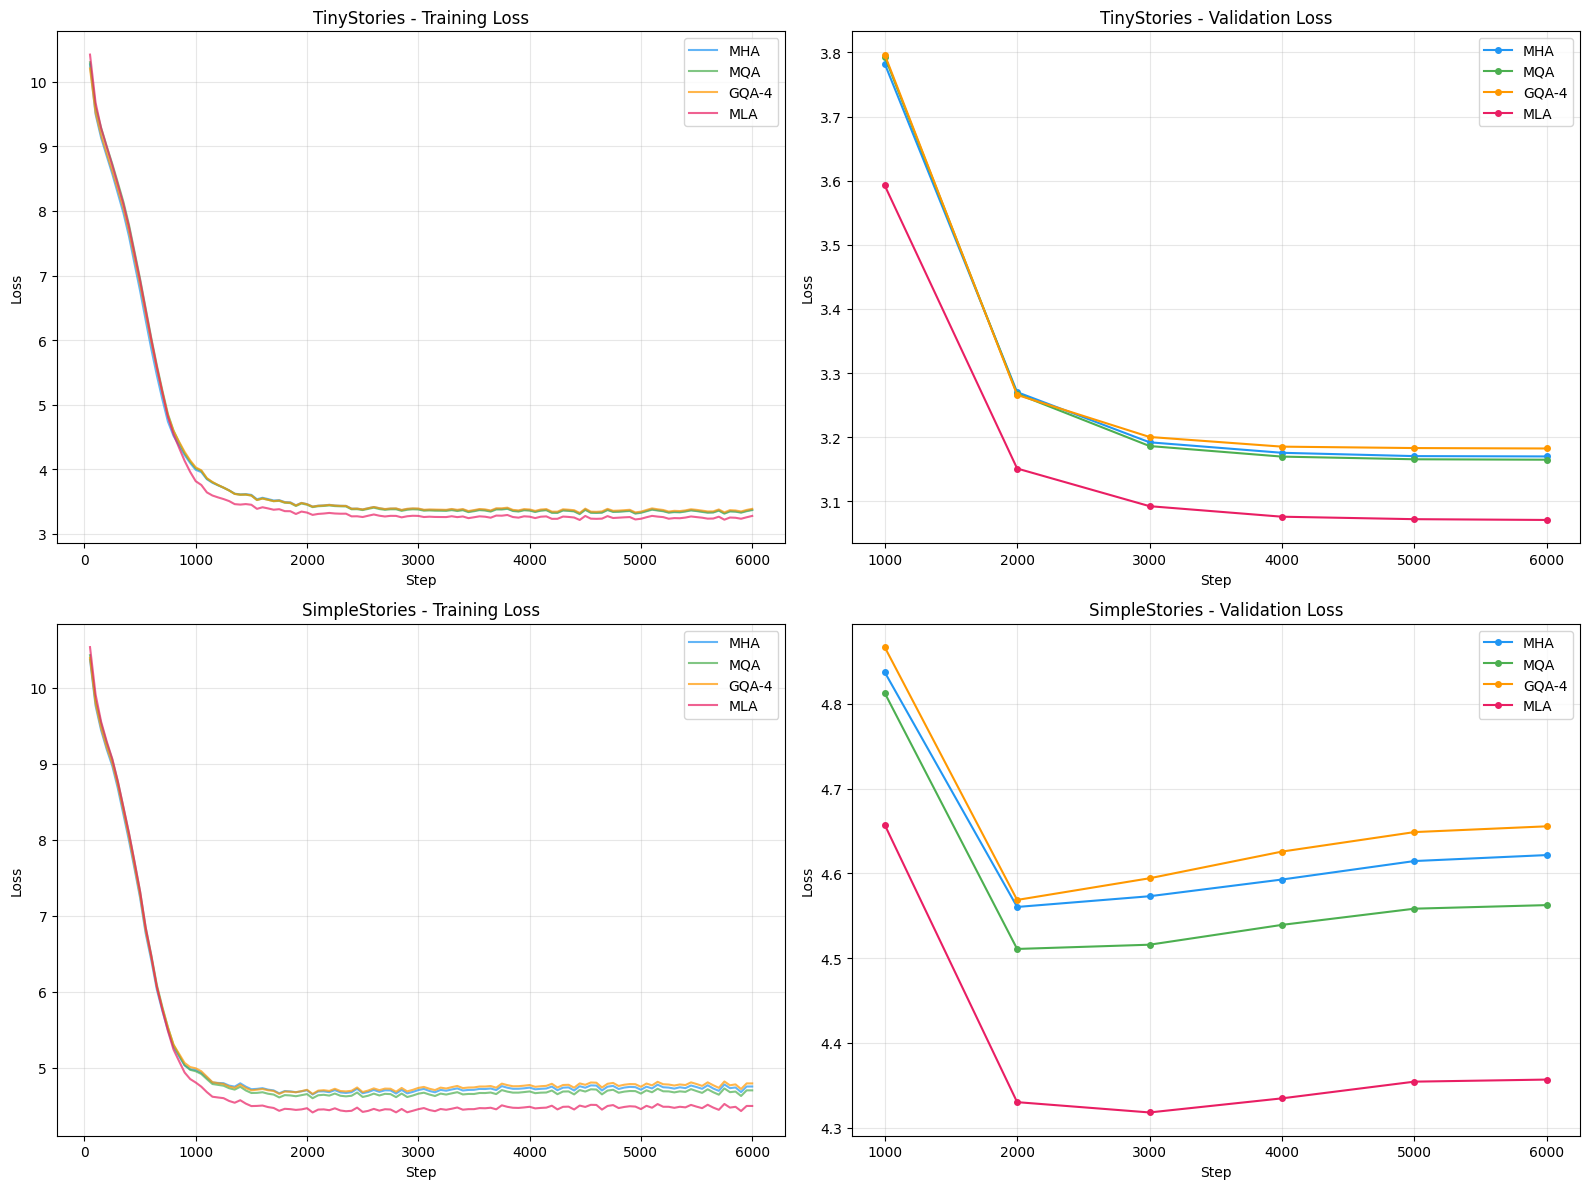

In [17]:
from tensorboard.backend.event_processing import event_accumulator

# Copy logs from Drive to local (faster reads)
DRIVE_LOGS = f'{DRIVE_BASE}/logs'
LOCAL_LOGS = '/content/logs'
if os.path.exists(DRIVE_LOGS):
    if os.path.exists(LOCAL_LOGS):
        shutil.rmtree(LOCAL_LOGS)
    shutil.copytree(DRIVE_LOGS, LOCAL_LOGS)
    print(f"Copied logs from Drive to {LOCAL_LOGS}")

log_dirs = {
    'TinyStories': {
        'MHA': f'{LOCAL_LOGS}/gptneo_mha_tinystories',
        'MQA': f'{LOCAL_LOGS}/gptneo_mqa_tinystories',
        'GQA-4': f'{LOCAL_LOGS}/gptneo_gqa_tinystories',
        'MLA': f'{LOCAL_LOGS}/gptneo_mla_tinystories',
    },
    'SimpleStories': {
        'MHA': f'{LOCAL_LOGS}/gptneo_mha_simplestories',
        'MQA': f'{LOCAL_LOGS}/gptneo_mqa_simplestories',
        'GQA-4': f'{LOCAL_LOGS}/gptneo_gqa_simplestories',
        'MLA': f'{LOCAL_LOGS}/gptneo_mla_simplestories',
    }
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, dataset in enumerate(['TinyStories', 'SimpleStories']):
    for name, log_dir in log_dirs[dataset].items():
        try:
            ea = event_accumulator.EventAccumulator(log_dir)
            ea.Reload()

            # Training loss
            train_loss = ea.Scalars('train/loss')
            axes[row, 0].plot([x.step for x in train_loss], [x.value for x in train_loss],
                             label=name, color=colors[name], alpha=0.7)

            # Val loss
            val_loss = ea.Scalars('val/loss')
            axes[row, 1].plot([x.step for x in val_loss], [x.value for x in val_loss],
                             label=name, color=colors[name], marker='o', markersize=4)
        except Exception as e:
            print(f"Could not load {name} {dataset} logs: {e}")

    axes[row, 0].set_title(f'{dataset} - Training Loss')
    axes[row, 0].set_xlabel('Step')
    axes[row, 0].set_ylabel('Loss')
    axes[row, 0].legend()
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].set_title(f'{dataset} - Validation Loss')
    axes[row, 1].set_xlabel('Step')
    axes[row, 1].set_ylabel('Loss')
    axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Convergence speed: step to reach 90% of final val loss reduction
print("Convergence Speed: Steps to reach 90% of final performance")
print("=" * 70)

for dataset in ['TinyStories', 'SimpleStories']:
    print(f"\n{dataset}:")
    for name, log_dir in log_dirs[dataset].items():
        try:
            ea = event_accumulator.EventAccumulator(log_dir)
            ea.Reload()
            val_loss = ea.Scalars('val/loss')
            if len(val_loss) < 2:
                continue
            steps = [x.step for x in val_loss]
            losses = [x.value for x in val_loss]
            initial_loss = losses[0]
            final_loss = losses[-1]
            target = initial_loss - 0.9 * (initial_loss - final_loss)
            conv_step = steps[-1]  # default to last step
            for s, l in zip(steps, losses):
                if l <= target:
                    conv_step = s
                    break
            print(f"  {name}: step {conv_step} (final loss: {final_loss:.4f})")
        except Exception as e:
            print(f"  {name}: could not compute - {e}")

Convergence Speed: Steps to reach 90% of final performance

TinyStories:
  MHA: step 3000 (final loss: 3.1701)
  MQA: step 3000 (final loss: 3.1650)
  GQA-4: step 3000 (final loss: 3.1824)
  MLA: step 3000 (final loss: 3.0710)

SimpleStories:
  MHA: step 2000 (final loss: 4.6215)
  MQA: step 2000 (final loss: 4.5625)
  GQA-4: step 2000 (final loss: 4.6554)
  MLA: step 2000 (final loss: 4.3567)


## 13. Dataset Sensitivity Analysis

Dataset Sensitivity: PPL Comparison
Model          TinyStories   SimpleStories       Diff    Rank TS    Rank SS
----------------------------------------------------------------------
MHA                  69.08          236.01    +166.93          3          4 (changed!)
MQA                  67.39          218.91    +151.52          2          2
GQA-4                69.26          235.38    +166.12          4          3 (changed!)
MLA                  59.86          173.91    +114.04          1          1


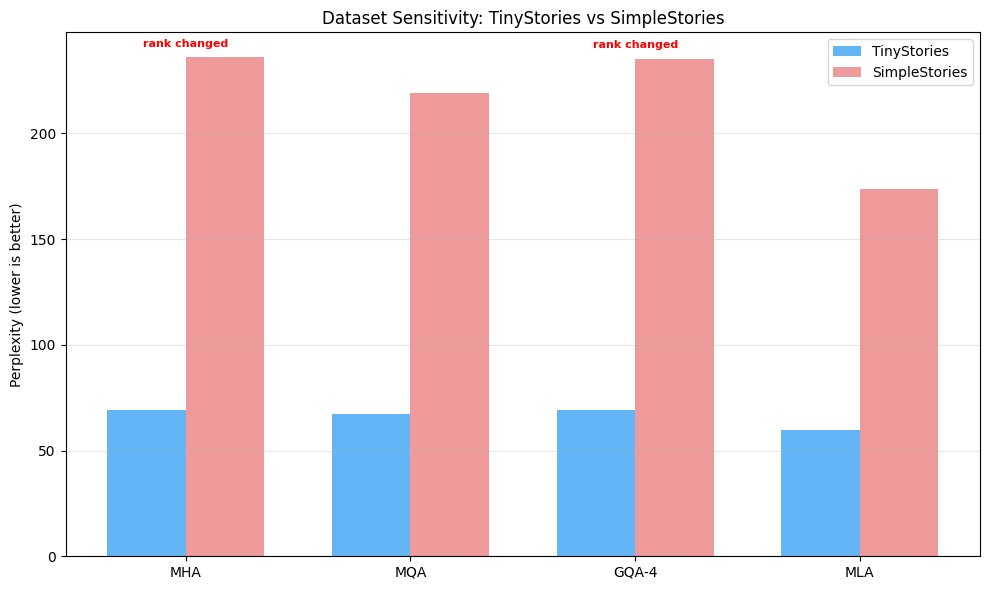

In [19]:
# Grouped bar: TinyStories vs SimpleStories PPL per mechanism
print("Dataset Sensitivity: PPL Comparison")
print("=" * 70)
print(f"{'Model':<10} {'TinyStories':>15} {'SimpleStories':>15} {'Diff':>10} {'Rank TS':>10} {'Rank SS':>10}")
print("-" * 70)

ts_ppls = {}
ss_ppls = {}
for name in model_names:
    ts_ppl = results.get('TinyStories', {}).get(name, {}).get('perplexity', float('inf'))
    ss_ppl = results.get('SimpleStories', {}).get(name, {}).get('perplexity', float('inf'))
    ts_ppls[name] = ts_ppl
    ss_ppls[name] = ss_ppl

# Compute ranks
ts_ranked = sorted(ts_ppls.items(), key=lambda x: x[1])
ss_ranked = sorted(ss_ppls.items(), key=lambda x: x[1])
ts_rank = {name: i+1 for i, (name, _) in enumerate(ts_ranked)}
ss_rank = {name: i+1 for i, (name, _) in enumerate(ss_ranked)}

for name in model_names:
    ts_p = ts_ppls[name]
    ss_p = ss_ppls[name]
    diff = ss_p - ts_p
    rank_change = "" if ts_rank[name] == ss_rank[name] else f" (changed!)"
    print(f"{name:<10} {ts_p:>15.2f} {ss_p:>15.2f} {diff:>+10.2f} {ts_rank[name]:>10} {ss_rank[name]:>10}{rank_change}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(model_names))
width = 0.35

ts_vals = [ts_ppls[n] for n in model_names]
ss_vals = [ss_ppls[n] for n in model_names]

ax.bar(x - width/2, ts_vals, width, label='TinyStories', color='#64B5F6')
ax.bar(x + width/2, ss_vals, width, label='SimpleStories', color='#EF9A9A')

ax.set_ylabel('Perplexity (lower is better)')
ax.set_title('Dataset Sensitivity: TinyStories vs SimpleStories')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Highlight ranking changes
for i, name in enumerate(model_names):
    if ts_rank[name] != ss_rank[name]:
        ax.annotate('rank changed', (i, max(ts_ppls[name], ss_ppls[name]) + 5),
                   ha='center', fontsize=8, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/dataset_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Efficiency-Quality Tradeoff

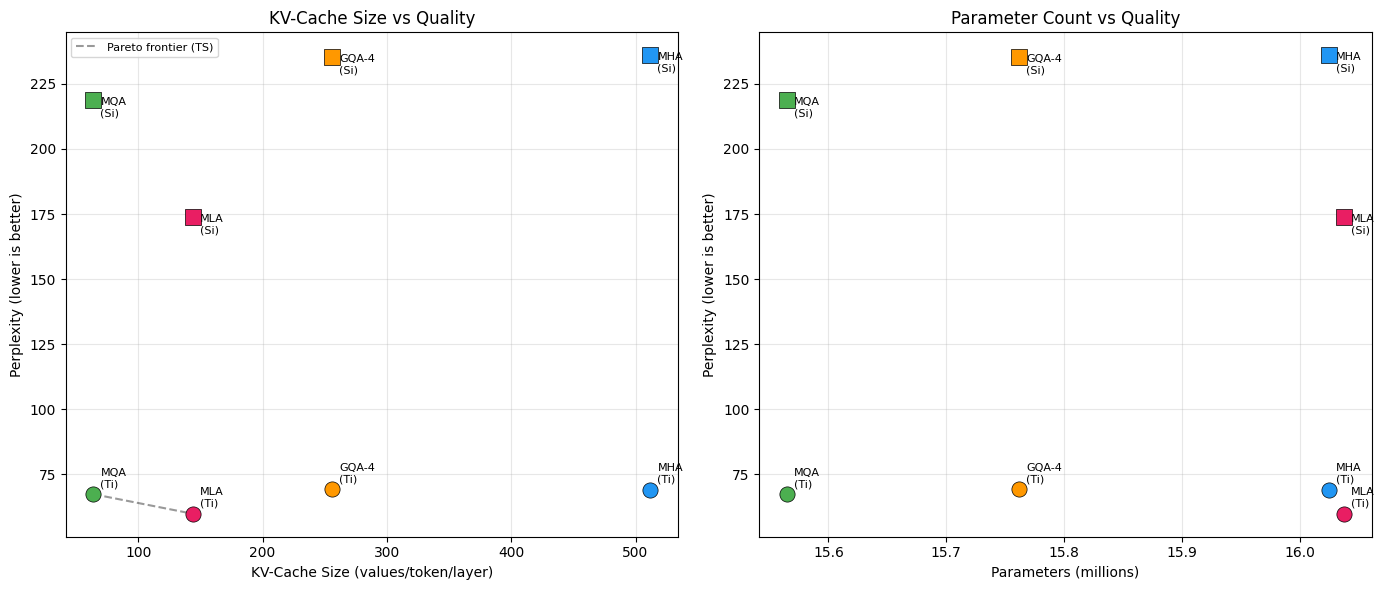

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Scatter 1: KV cache size vs PPL
for dataset, marker in [('TinyStories', 'o'), ('SimpleStories', 's')]:
    for name in model_names:
        ppl = results.get(dataset, {}).get(name, {}).get('perplexity', None)
        if ppl is not None:
            ax1.scatter(kv_cache[name], ppl, color=colors[name], marker=marker,
                       s=120, zorder=5, edgecolors='black', linewidth=0.5)
            label_offset = (5, 5) if dataset == 'TinyStories' else (5, -12)
            ax1.annotate(f'{name}\n({dataset[:2]})',
                        (kv_cache[name], ppl), textcoords='offset points',
                        xytext=label_offset, fontsize=8)

ax1.set_xlabel('KV-Cache Size (values/token/layer)')
ax1.set_ylabel('Perplexity (lower is better)')
ax1.set_title('KV-Cache Size vs Quality')
ax1.grid(True, alpha=0.3)

# Pareto frontier (TinyStories)
ts_points = []
for name in model_names:
    ppl = results.get('TinyStories', {}).get(name, {}).get('perplexity', None)
    if ppl is not None:
        ts_points.append((kv_cache[name], ppl, name))
ts_points.sort(key=lambda p: p[0])

# Simple Pareto: keep only points where PPL improves as KV increases
pareto = [ts_points[0]]
for p in ts_points[1:]:
    if p[1] < pareto[-1][1]:
        pareto.append(p)
if len(pareto) > 1:
    ax1.plot([p[0] for p in pareto], [p[1] for p in pareto],
            'k--', alpha=0.4, label='Pareto frontier (TS)')
    ax1.legend(fontsize=8)

# Scatter 2: Param count vs PPL
for dataset, marker in [('TinyStories', 'o'), ('SimpleStories', 's')]:
    for name in model_names:
        ppl = results.get(dataset, {}).get(name, {}).get('perplexity', None)
        if ppl is not None and name in param_data:
            params_m = param_data[name]['total'] / 1e6
            ax2.scatter(params_m, ppl, color=colors[name], marker=marker,
                       s=120, zorder=5, edgecolors='black', linewidth=0.5)
            label_offset = (5, 5) if dataset == 'TinyStories' else (5, -12)
            ax2.annotate(f'{name}\n({dataset[:2]})',
                        (params_m, ppl), textcoords='offset points',
                        xytext=label_offset, fontsize=8)

ax2.set_xlabel('Parameters (millions)')
ax2.set_ylabel('Perplexity (lower is better)')
ax2.set_title('Parameter Count vs Quality')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/efficiency_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Comprehensive Summary Table

In [21]:
def pct_diff(val, baseline):
    if baseline == 0:
        return 0
    return ((val - baseline) / baseline) * 100

for dataset in ['TinyStories', 'SimpleStories']:
    print(f"\n{'='*110}")
    print(f"COMPREHENSIVE COMPARISON: {dataset}")
    print(f"{'='*110}")
    print(f"{'Metric':<25} {'MHA (baseline)':>15} {'MQA':>20} {'GQA-4':>20} {'MLA':>20}")
    print("-" * 110)

    # Params
    mha_params = param_data.get('MHA', {}).get('total', 0)
    for name in model_names:
        p = param_data.get(name, {}).get('total', 0)
    row = ['Parameters']
    for name in model_names:
        p = param_data.get(name, {}).get('total', 0)
        if name == 'MHA':
            row.append(f"{p:,}")
        else:
            row.append(f"{p:,} ({pct_diff(p, mha_params):+.1f}%)")
    print(f"{row[0]:<25} {row[1]:>15} {row[2]:>20} {row[3]:>20} {row[4]:>20}")

    # KV Cache
    mha_kv = kv_cache['MHA']
    row = ['KV Cache/token/layer']
    for name in model_names:
        kv = kv_cache[name]
        if name == 'MHA':
            row.append(str(kv))
        else:
            row.append(f"{kv} ({pct_diff(kv, mha_kv):+.1f}%)")
    print(f"{row[0]:<25} {row[1]:>15} {row[2]:>20} {row[3]:>20} {row[4]:>20}")

    # Perplexity
    mha_ppl = results.get(dataset, {}).get('MHA', {}).get('perplexity', 0)
    row = ['Perplexity']
    for name in model_names:
        ppl = results.get(dataset, {}).get(name, {}).get('perplexity', 0)
        if name == 'MHA':
            row.append(f"{ppl:.2f}")
        else:
            row.append(f"{ppl:.2f} ({pct_diff(ppl, mha_ppl):+.1f}%)")
    print(f"{row[0]:<25} {row[1]:>15} {row[2]:>20} {row[3]:>20} {row[4]:>20}")

    # Top-k accuracy
    for k in [1, 5, 10]:
        mha_acc = acc_results.get(dataset, {}).get('MHA', {}).get(k, 0)
        row = [f'Top-{k} Accuracy (%)']
        for name in model_names:
            acc = acc_results.get(dataset, {}).get(name, {}).get(k, 0)
            if name == 'MHA':
                row.append(f"{acc:.2f}")
            else:
                row.append(f"{acc:.2f} ({pct_diff(acc, mha_acc):+.1f}%)")
        print(f"{row[0]:<25} {row[1]:>15} {row[2]:>20} {row[3]:>20} {row[4]:>20}")

    # Speed @ 256
    mha_speed = speed_results.get('MHA', {}).get(256, 0)
    row = ['Speed @256 (tok/s)']
    for name in model_names:
        sp = speed_results.get(name, {}).get(256, 0)
        if name == 'MHA':
            row.append(f"{sp:,.0f}")
        else:
            row.append(f"{sp:,.0f} ({pct_diff(sp, mha_speed):+.1f}%)")
    print(f"{row[0]:<25} {row[1]:>15} {row[2]:>20} {row[3]:>20} {row[4]:>20}")

    # Memory
    mha_mem = memory_results.get('MHA', 0)
    row = ['Peak Memory (MB)']
    for name in model_names:
        mem = memory_results.get(name, 0)
        if name == 'MHA':
            row.append(f"{mem:.0f}")
        else:
            row.append(f"{mem:.0f} ({pct_diff(mem, mha_mem):+.1f}%)")
    print(f"{row[0]:<25} {row[1]:>15} {row[2]:>20} {row[3]:>20} {row[4]:>20}")

    # Diversity
    for dn in ['d1', 'd2', 'd3']:
        label = f'Distinct-{dn[-1]}'
        mha_d = diversity_results.get(dataset, {}).get('MHA', {}).get(dn, 0)
        row = [label]
        for name in model_names:
            d = diversity_results.get(dataset, {}).get(name, {}).get(dn, 0)
            if name == 'MHA':
                row.append(f"{d:.4f}")
            else:
                row.append(f"{d:.4f} ({pct_diff(d, mha_d):+.1f}%)")
        print(f"{row[0]:<25} {row[1]:>15} {row[2]:>20} {row[3]:>20} {row[4]:>20}")

    # Repetition rate
    mha_rep = diversity_results.get(dataset, {}).get('MHA', {}).get('rep', 0)
    row = ['Repetition Rate']
    for name in model_names:
        rep = diversity_results.get(dataset, {}).get(name, {}).get('rep', 0)
        if name == 'MHA':
            row.append(f"{rep:.4f}")
        else:
            row.append(f"{rep:.4f} ({pct_diff(rep, mha_rep):+.1f}%)")
    print(f"{row[0]:<25} {row[1]:>15} {row[2]:>20} {row[3]:>20} {row[4]:>20}")

    print("=" * 110)


COMPREHENSIVE COMPARISON: TinyStories
Metric                     MHA (baseline)                  MQA                GQA-4                  MLA
--------------------------------------------------------------------------------------------------------------
Parameters                     16,025,344   15,564,800 (-2.9%)   15,762,176 (-1.6%)   16,037,632 (+0.1%)
KV Cache/token/layer                  512          64 (-87.5%)         256 (-50.0%)         144 (-71.9%)
Perplexity                          69.08        67.39 (-2.5%)        69.26 (+0.3%)       59.86 (-13.3%)
Top-1 Accuracy (%)                  33.65        33.73 (+0.2%)        33.72 (+0.2%)        34.16 (+1.5%)
Top-5 Accuracy (%)                  54.88        55.14 (+0.5%)        55.00 (+0.2%)        55.84 (+1.7%)
Top-10 Accuracy (%)                 63.09        63.39 (+0.5%)        63.20 (+0.2%)        64.08 (+1.6%)
Speed @256 (tok/s)                 44,187       43,011 (-2.7%)       43,177 (-2.3%)       40,030 (-9.4%)
Peak Memor

## 16. Conclusion & Save Results

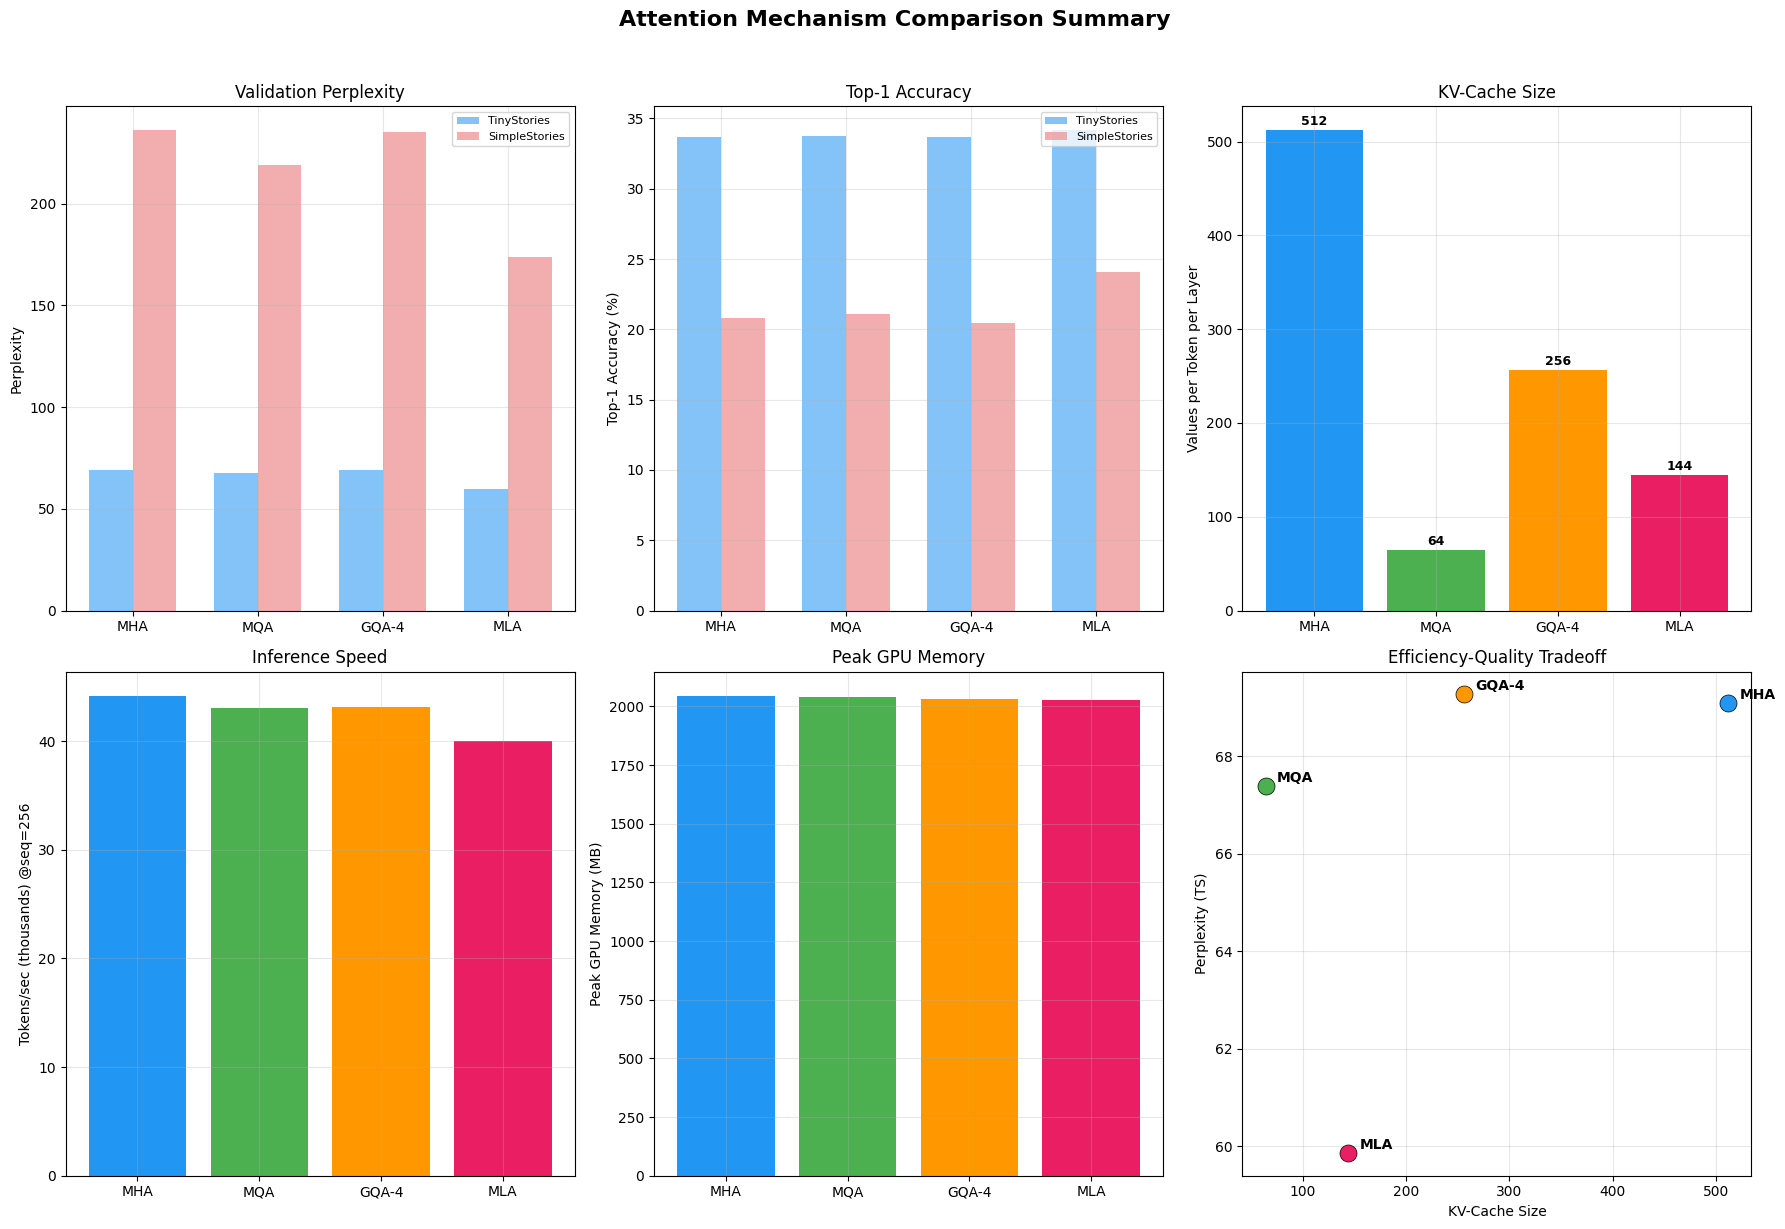

In [22]:
# Multi-panel summary figure
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Perplexity
ax = axes[0, 0]
x = np.arange(len(model_names))
width = 0.35
for i, dataset in enumerate(['TinyStories', 'SimpleStories']):
    ppls = [results.get(dataset, {}).get(n, {}).get('perplexity', 0) for n in model_names]
    ax.bar(x + i*width, ppls, width, label=dataset, alpha=0.8,
           color='#64B5F6' if i == 0 else '#EF9A9A')
ax.set_ylabel('Perplexity')
ax.set_title('Validation Perplexity')
ax.set_xticks(x + width/2)
ax.set_xticklabels(model_names)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. Top-1 Accuracy
ax = axes[0, 1]
for i, dataset in enumerate(['TinyStories', 'SimpleStories']):
    accs = [acc_results.get(dataset, {}).get(n, {}).get(1, 0) for n in model_names]
    ax.bar(x + i*width, accs, width, label=dataset, alpha=0.8,
           color='#64B5F6' if i == 0 else '#EF9A9A')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('Top-1 Accuracy')
ax.set_xticks(x + width/2)
ax.set_xticklabels(model_names)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3. KV Cache
ax = axes[0, 2]
kv_sizes = [kv_cache[n] for n in model_names]
bars = ax.bar(model_names, kv_sizes, color=color_list)
ax.set_ylabel('Values per Token per Layer')
ax.set_title('KV-Cache Size')
for bar, size in zip(bars, kv_sizes):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
            str(size), ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.grid(True, alpha=0.3)

# 4. Speed
ax = axes[1, 0]
speeds = [speed_results.get(n, {}).get(256, 0) / 1000 for n in model_names]
bars = ax.bar(model_names, speeds, color=color_list)
ax.set_ylabel('Tokens/sec (thousands) @seq=256')
ax.set_title('Inference Speed')
ax.grid(True, alpha=0.3)

# 5. Memory
ax = axes[1, 1]
mems = [memory_results.get(n, 0) for n in model_names]
bars = ax.bar(model_names, mems, color=color_list)
ax.set_ylabel('Peak GPU Memory (MB)')
ax.set_title('Peak GPU Memory')
ax.grid(True, alpha=0.3)

# 6. Efficiency tradeoff scatter
ax = axes[1, 2]
for name in model_names:
    ppl = results.get('TinyStories', {}).get(name, {}).get('perplexity', None)
    if ppl is not None:
        ax.scatter(kv_cache[name], ppl, color=colors[name], s=150, zorder=5,
                  edgecolors='black', linewidth=0.5)
        ax.annotate(name, (kv_cache[name], ppl), textcoords='offset points',
                   xytext=(8, 3), fontsize=10, fontweight='bold')
ax.set_xlabel('KV-Cache Size')
ax.set_ylabel('Perplexity (TS)')
ax.set_title('Efficiency-Quality Tradeoff')
ax.grid(True, alpha=0.3)

plt.suptitle('Attention Mechanism Comparison Summary', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/summary_figure.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Save all results to JSON
export_data = {
    'models': model_names,
    'param_data': {n: {k: int(v) for k, v in d.items()} for n, d in param_data.items()},
    'kv_cache': kv_cache,
    'kv_flops': kv_flops,
    'attn_flops': attn_flops,
    'arith_intensity': arith_intensity,
    'perplexity': {
        ds: {n: {'loss': d['loss'], 'perplexity': d['perplexity']}
             for n, d in ds_results.items()}
        for ds, ds_results in results.items()
    },
    'topk_accuracy': {
        ds: {n: {str(k): v for k, v in d.items()} for n, d in ds_results.items()}
        for ds, ds_results in acc_results.items()
    },
    'diversity': {
        ds: ds_results for ds, ds_results in diversity_results.items()
    },
    'speed': {n: {str(k): v for k, v in d.items()} for n, d in speed_results.items()},
    'memory': memory_results,
}

# Save to Drive
drive_results_path = f'{DRIVE_BASE}/evaluation_results.json'
with open(drive_results_path, 'w') as f:
    json.dump(export_data, f, indent=2, default=str)
print(f"Results saved to: {drive_results_path}")

# Copy charts to Drive
drive_charts_dir = f'{DRIVE_BASE}/charts'
if os.path.exists(drive_charts_dir):
    shutil.rmtree(drive_charts_dir)
shutil.copytree(CHARTS_DIR, drive_charts_dir)
print(f"Charts saved to: {drive_charts_dir}")

# Save sample generations
gen_path = f'{DRIVE_BASE}/sample_generations.txt'
with open(gen_path, 'w') as f:
    for dataset in ['TinyStories', 'SimpleStories']:
        f.write(f"\n{'='*80}\n{dataset}\n{'='*80}\n")
        for prompt in prompts:
            f.write(f"\nPrompt: \"{prompt}\"\n{'-'*80}\n")
            for name in model_names:
                if name in models[dataset]:
                    model = models[dataset][name]
                    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
                    with torch.no_grad():
                        output = model.generate(input_ids, max_length=100, temperature=0.8, top_k=50, top_p=0.95)
                    text = tokenizer.decode(output[0], skip_special_tokens=True)
                    f.write(f"\n[{name}]: {text}\n")
print(f"Sample generations saved to: {gen_path}")

# List all saved files
print(f"\nAll saved files in {DRIVE_BASE}:")
print("-" * 60)
for root, dirs, files in os.walk(DRIVE_BASE):
    for f in sorted(files):
        fpath = os.path.join(root, f)
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        rel_path = os.path.relpath(fpath, DRIVE_BASE)
        print(f"  {rel_path:<50} {size_mb:>8.2f} MB")

Results saved to: /content/drive/MyDrive/AttentionHeads_RoPE_50pct/evaluation_results.json
Charts saved to: /content/drive/MyDrive/AttentionHeads_RoPE_50pct/charts
Sample generations saved to: /content/drive/MyDrive/AttentionHeads_RoPE_50pct/sample_generations.txt

All saved files in /content/drive/MyDrive/AttentionHeads_RoPE_50pct:
------------------------------------------------------------
  evaluation_results.json                                0.00 MB
  sample_generations.txt                                 0.01 MB
  TinyStories/best_model_gqa_ts_50pct.pt               180.72 MB
  TinyStories/best_model_mha_ts_50pct.pt               183.73 MB
  TinyStories/best_model_mla_ts_50pct.pt               183.74 MB
  TinyStories/best_model_mqa_ts_50pct.pt               178.46 MB
  SimpleStories/best_model_gqa_ss_50pct.pt             180.72 MB
  SimpleStories/best_model_mha_ss_50pct.pt             183.73 MB
  SimpleStories/best_model_mla_ss_50pct.pt             183.74 MB
  SimpleStories/bes

In [24]:
# Download as zip
from google.colab import files

zip_path = '/content/attention_comparison_results'
shutil.make_archive(zip_path, 'zip', CHARTS_DIR)
print(f"Created: {zip_path}.zip")
print("Downloading...")
files.download(f'{zip_path}.zip')

Created: /content/attention_comparison_results.zip
Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Key Findings

### Attention Mechanisms Compared
| Feature | MHA | MQA | GQA-4 | MLA |
|---------|-----|-----|-------|-----|
| KV Cache | 512 (1.0x) | 64 (0.125x) | 256 (0.5x) | 144 (0.28x) |
| Quality | Baseline | Lower | Close to MHA | Close to MHA |
| Speed | Baseline | Fastest | Fast | Moderate |
| Arith Intensity | Low | Low | Low | High |

### Key Insights
- **MHA** provides the best quality baseline but with the largest KV-cache
- **MQA** achieves 8x KV-cache reduction but with noticeable quality degradation
- **GQA-4** offers a balanced tradeoff: 2x KV-cache reduction with near-MHA quality
- **MLA** achieves 3.5x KV-cache reduction while maintaining quality close to MHA, with highest arithmetic intensity

### References
- MHA: Vaswani et al. (2017) - arXiv:1706.03762
- MQA: Shazeer (2019) - arXiv:1911.02150
- GQA: Ainslie et al. (2023) - arXiv:2305.13245
- MLA: DeepSeek-AI (2024) - arXiv:2405.04434
- RoPE: Su et al. (2021) - arXiv:2104.09864
- TinyStories: Eldan & Li (2023) - arXiv:2305.07759
- SimpleStories: Finke et al. (2025) - arXiv:2504.09184